<a href="https://colab.research.google.com/github/mishael-fav/EDA_MARKETING_CAMPAIGN/blob/main/Marketing_Campaign_Data_Analysis_MAIN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MARKET CAMPAIGN ANALYSIS 📈📊**


## **Business Objective**
---
- The primary objective of this project is to evaluate and optimize marketing campaign performance across multiple companies, channels, and customer segments.
- By analyzing key performance indicators (KPIs) such as revenue, `CTR (Click-Through Rate)`, `CPC (Cost Per Click)`, conversion rate, and ROI, the goal is to identify high-performing campaigns, uncover underperforming areas, and determine the most profitable marketing strategies.
- This analysis aims to provide actionable insights that will guide decision-making on campaign allocation, targeting strategies, and overall marketing investments to maximize return on marketing spend.

## **Project Overview**

This project focuses on conducting a comprehensive market campaign analysis to uncover patterns, trends, and profitability drivers across different campaigns and companies. The analysis will:

- **Revenue Insights** – Measure overall and company-level campaign revenue contributions.

- **Channel & Campaign Effectiveness** – Compare marketing channels (social media, email, display, etc.) and campaign types to evaluate effectiveness.

- **Performance Metrics** – Calculate CTR, CPC, conversion rates, and ROI to assess campaign efficiency.

- **Segmentation Analysis** – Identify the most profitable customer segments, target audiences, and locations for each company.

- **Market Trends** – Explore location-based and demographic/cultural factors that influence campaign success.

- **Optimization Strategy** – Recommend the best campaign type, marketing channel, and audience combinations that drive the highest profitability and engagement.

##### ***Deliverables will include interactive dashboards and visualizations that highlight preferred campaign types, marketing channels, audience responses, and ROI insights. These will enable stakeholders to prioritize resources, scale winning campaigns, and implement corrective strategies for underperforming ones.***

In [ ]:
# import the necessary python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

colors = sns.color_palette("husl", 10)
colors_pie = ['#D62828', '#F77F00', '#FCBF49', '#06A77D']

In [ ]:
#Load the dataset
market_cmp = pd.read_excel("/content/drive/MyDrive/marketing_campaign_dataset.xlsx")
market_cmp.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Date,Clicks,Impressions,Engagement_Score,Customer_Segment
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,16174,6.29,Chicago,2021-01-01 00:00:00,506,1922,6,Health & Wellness
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,11566,5.61,New York,2021-02-01 00:00:00,116,7523,7,Fashionistas
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,10200,7.18,Los Angeles,2021-03-01 00:00:00,584,7698,1,Outdoor Adventurers
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,12724,5.55,Miami,2021-04-01 00:00:00,217,1820,7,Health & Wellness
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,16452,6.50,Los Angeles,2021-05-01 00:00:00,379,4201,3,Health & Wellness


In [ ]:
# Inspect data
print(f"Dataset Shape: {market_cmp.shape}")
print(f"Number of Campaigns: {market_cmp.info()}")

Dataset Shape: (200005, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200005 entries, 0 to 200004
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       200005 non-null  int64  
 1   Company           200005 non-null  object 
 2   Campaign_Type     200005 non-null  object 
 3   Target_Audience   200005 non-null  object 
 4   Duration          200005 non-null  object 
 5   Channel_Used      200005 non-null  object 
 6   Conversion_Rate   200005 non-null  float64
 7   Acquisition_Cost  200005 non-null  int64  
 8   ROI               200005 non-null  float64
 9   Location          200005 non-null  object 
 10  Date              200005 non-null  object 
 11  Clicks            200005 non-null  int64  
 12  Impressions       200005 non-null  int64  
 13  Engagement_Score  200005 non-null  int64  
 14  Customer_Segment  200005 non-null  object 
dtypes: float64(2), int64(5), object(8)
memor

In [ ]:
market_cmp["ROI"].mean()

np.float64(5.00241643958901)

**DATA QUALITY CHECK**

In [ ]:
# Check for missing values
market_cmp.isnull().sum()

,0
Campaign_ID,0
Company,0
Campaign_Type,0
Target_Audience,0
Duration,0
Channel_Used,0
Conversion_Rate,0
Acquisition_Cost,0
ROI,0
Location,0


In [ ]:
# Check for duplicates
market_cmp.duplicated().sum()

np.int64(0)

In [ ]:
# Inspect and rectify the inconsistency in the date column
def parse_mixed_dates(date_str):

    if pd.isna(date_str):
        return pd.NaT

    # Convert to string if not already
    date_str = str(date_str).strip()

    try:
        # Try parsing as DD/MM/YYYY first (European format)
        return pd.to_datetime(date_str, format='%d/%m/%Y')
    except:
        try:
            # If that fails, try other common formats
            return pd.to_datetime(date_str, dayfirst=True)
        except:
            # Return NaT (Not a Time) for unparseable dates
            return pd.NaT

# Apply to main database
market_cmp['Date'] = market_cmp['Date'].apply(parse_mixed_dates)


In [ ]:
market_cmp['Date'].iloc[10:].head()

,Date
10,2021-01-11
11,2021-01-12
12,2021-01-13
13,2021-01-14
14,2021-01-15


In [ ]:
# Splitting Target_Audience into Gender and Age_Group
def split_target_audience(value):
    if value == 'All Ages':
        return pd.Series(['All', 'All Ages'])
    else:
        parts = value.split(' ')
        gender = parts[0]
        age = parts[1] if len(parts) > 1 else None
        return pd.Series([gender, age])

market_cmp[['Gender', 'Age_Group']] = market_cmp['Target_Audience'].apply(split_target_audience)


In [ ]:
# Clean the Duration; Remove the 'days'
market_cmp["Duration"] = market_cmp["Duration"].str.extract(r'(\d+)').astype(int)

In [ ]:
market_cmp["Duration"].head()

,Duration
0,30
1,60
2,30
3,60
4,15


**CREATE CALCULATED KPI METRICS**

In [ ]:
# Calculate the Revenue and profit
market_cmp["Revenue"] = market_cmp["Acquisition_Cost"] * (1 + market_cmp["ROI"])
market_cmp["Profit"] = market_cmp["Revenue"] - market_cmp["Acquisition_Cost"]

In [ ]:
# Calculate essential KPIs
market_cmp['CTR'] = (market_cmp['Clicks'] / market_cmp['Impressions']) * 100
market_cmp['CPC'] = market_cmp['Acquisition_Cost'] / market_cmp['Clicks']
market_cmp['CPM'] = (market_cmp['Acquisition_Cost'] / market_cmp['Impressions']) * 1000
market_cmp['ROAS'] = market_cmp['Revenue'] / market_cmp['Acquisition_Cost']
market_cmp['Revenue_Per_Click'] = market_cmp['Revenue'] / market_cmp['Clicks']
market_cmp['Profit_Margin'] = (market_cmp['Profit'] / market_cmp['Revenue']) * 100
market_cmp['CPA'] = market_cmp['Acquisition_Cost'] / (market_cmp['Clicks'] * market_cmp['Conversion_Rate'] / 100)


In [ ]:
# Create ROI categories
market_cmp['ROI_Category'] = pd.cut(market_cmp['ROI'],
                              bins=[-np.inf, 0, 50, 100, np.inf],
                              labels=['Poor (<0%)', 'Moderate (0-50%)', 'Good (50-100%)', 'Excellent (>100%)'])

In [ ]:
market_cmp[['Campaign_ID', 'Company','Revenue', 'CTR', 'CPC',
       'CPM', 'ROAS', 'Revenue_Per_Click', 'Profit_Margin', 'CPA', 'ROI_Category']].head()

,Campaign_ID,Company,Revenue,CTR,CPC,CPM,ROAS,Revenue_Per_Click,Profit_Margin,CPA,ROI_Category
0,1,Innovate Industries,117908.46,26.326743,31.964427,8415.192508,7.29,233.020672,86.282579,79911.067194,Moderate (0-50%)
1,2,NexGen Systems,76451.26,1.541938,99.706897,1537.418583,6.61,659.062586,84.871407,83089.080460,Moderate (0-50%)
2,3,Alpha Innovations,83436.00,7.586386,17.465753,1325.019486,8.18,142.869863,87.775061,24951.076321,Moderate (0-50%)
3,4,DataTech Solutions,83342.20,11.923077,58.635945,6991.208791,6.55,384.065438,84.732824,53305.404273,Moderate (0-50%)
4,5,NexGen Systems,123390.00,9.021662,43.408971,3916.210426,7.50,325.567282,86.666667,86817.941953,Moderate (0-50%)


In [ ]:
pd.set_option('display.max_columns', None)
market_cmp.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Date,Clicks,Impressions,Engagement_Score,Customer_Segment,Gender,Age_Group,Revenue,Profit,CTR,CPC,CPM,ROAS,Revenue_Per_Click,Profit_Margin,CPA,ROI_Category
0,1,Innovate Industries,Email,Men 18-24,30,Google Ads,0.04,16174,6.29,Chicago,2021-01-01,506,1922,6,Health & Wellness,Men,18-24,117908.46,101734.46,26.326743,31.964427,8415.192508,7.29,233.020672,86.282579,79911.067194,Moderate (0-50%)
1,2,NexGen Systems,Email,Women 35-44,60,Google Ads,0.12,11566,5.61,New York,2021-01-02,116,7523,7,Fashionistas,Women,35-44,76451.26,64885.26,1.541938,99.706897,1537.418583,6.61,659.062586,84.871407,83089.080460,Moderate (0-50%)
2,3,Alpha Innovations,Influencer,Men 25-34,30,YouTube,0.07,10200,7.18,Los Angeles,2021-01-03,584,7698,1,Outdoor Adventurers,Men,25-34,83436.00,73236.00,7.586386,17.465753,1325.019486,8.18,142.869863,87.775061,24951.076321,Moderate (0-50%)
3,4,DataTech Solutions,Display,All Ages,60,YouTube,0.11,12724,5.55,Miami,2021-01-04,217,1820,7,Health & Wellness,All,All Ages,83342.20,70618.20,11.923077,58.635945,6991.208791,6.55,384.065438,84.732824,53305.404273,Moderate (0-50%)
4,5,NexGen Systems,Email,Men 25-34,15,YouTube,0.05,16452,6.50,Los Angeles,2021-01-05,379,4201,3,Health & Wellness,Men,25-34,123390.00,106938.00,9.021662,43.408971,3916.210426,7.50,325.567282,86.666667,86817.941953,Moderate (0-50%)


In [ ]:
summary_metrics = {
    'Total Revenue': f"${market_cmp['Revenue'].sum():,.2f}",
    'Total Profit': f"${market_cmp['Profit'].sum():,.2f}",
    'Total Acquisition Cost': f"${market_cmp['Acquisition_Cost'].sum():,.2f}",
    'Average ROI': f"{market_cmp['ROI'].mean():.2f}%",
    'Average CTR': f"{market_cmp['CTR'].mean():.2f}%",
    'Average CPC': f"${market_cmp['CPC'].mean():.2f}",
    'Average Conversion Rate': f"{market_cmp['Conversion_Rate'].mean():.2f}%",
    'Average ROAS': f"{market_cmp['ROAS'].mean():.2f}x",
    'Total Campaigns': market_cmp['Campaign_ID'].nunique(),
    'Total Clicks': f"{market_cmp['Clicks'].sum():,}",
    'Total Impressions': f"{market_cmp['Impressions'].sum():,}"
}

for metric, value in summary_metrics.items():
    print(f"{metric:.<40} {value:>20}")

Total Revenue...........................   $15,018,632,372.89
Total Profit............................   $12,517,681,491.89
Total Acquisition Cost..................    $2,500,950,881.00
Average ROI.............................                5.00%
Average CTR.............................               14.04%
Average CPC.............................               $32.01
Average Conversion Rate.................                0.08%
Average ROAS............................                6.00x
Total Campaigns.........................               200005
Total Clicks............................          109,957,667
Total Impressions.......................        1,101,488,958


**UNIVARIATE ANALYSIS - NUMERICAL**

In [ ]:
numerical_cols = ['Revenue', 'Profit', 'ROI', 'Conversion_Rate', 'CTR', 'CPC',
                  'Acquisition_Cost', 'Clicks', 'Impressions', 'Engagement_Score']

market_cmp[numerical_cols].describe().round(2)



,Revenue,Profit,ROI,Conversion_Rate,CTR,CPC,Acquisition_Cost,Clicks,Impressions,Engagement_Score
count,200005.00,200005.00,200005.00,200005.00,200005.00,200005.00,200005.00,200005.00,200005.00,200005.00
mean,75091.28,62586.84,5.00,0.08,14.04,32.01,12504.44,549.77,5507.31,5.49
std,34798.99,31667.35,1.73,0.04,13.09,26.93,4337.66,260.02,2596.86,2.87
min,15071.07,10064.07,2.00,0.01,1.01,5.02,5000.00,100.00,1000.00,1.00
25%,47728.22,37809.80,3.50,0.05,5.86,15.09,8740.00,325.00,3266.00,3.00
50%,68815.62,56193.30,5.01,0.08,9.98,22.77,12497.00,550.00,5518.00,5.00
75%,98146.30,83274.23,6.51,0.12,16.97,38.60,16264.00,775.00,7753.00,8.00
max,179438.36,159456.36,8.00,0.15,99.20,199.96,20000.00,1000.00,10000.00,10.00


In [ ]:
# Identify outliers
for col in ['Revenue', 'ROI', 'CPC', 'Acquisition_Cost']:
    Q1 = market_cmp[col].quantile(0.25)
    Q3 = market_cmp[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = market_cmp[(market_cmp[col] < Q1 - 1.5*IQR) | (market_cmp[col] > Q3 + 1.5*IQR)]
    if len(outliers) > 0:
        print(f"   {col}: {len(outliers)} outliers detected ({len(outliers)/len(market_cmp)*100:.1f}%)")

   Revenue: 222 outliers detected (0.1%)
   CPC: 16045 outliers detected (8.0%)


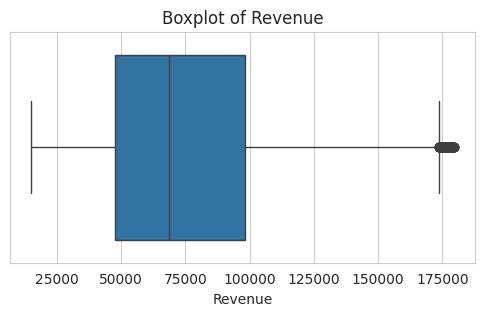

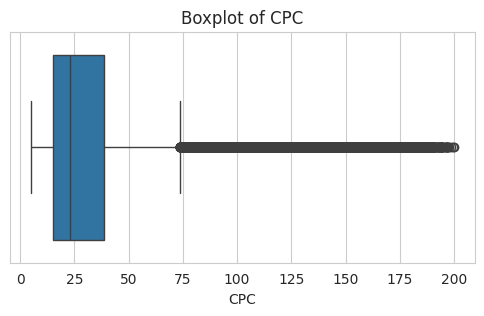

In [ ]:
# Boxplots to visualize outliers
for col in ['Revenue', 'CPC']:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=market_cmp[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


In [ ]:
# Handling the outliers
for col in ['CPC']:
    Q1 = market_cmp[col].quantile(0.25)
    Q3 = market_cmp[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    market_cmp[col] = market_cmp[col].clip(lower=lower_bound, upper=upper_bound)


**UNIVARIATE ANALYSIS - CATEGORICAL**

In [ ]:
categorical_cols = ['Campaign_Type', 'Channel_Used', 'Customer_Segment',
                    'Target_Audience', 'Gender', 'Age_Group', 'Location', 'Company']

for col in categorical_cols:
    print(f"\n{col} Distribution:")
    counts = market_cmp[col].value_counts()
    percentages = market_cmp[col].value_counts(normalize=True) * 100
    summary = pd.DataFrame({'Count': counts, 'Percentage': percentages})
    print(summary.head(10).to_string())


Campaign_Type Distribution:
               Count  Percentage
Campaign_Type                   
Influencer     40170   20.084498
Search         40157   20.077998
Display        39988   19.993500
Email          39871   19.935002
Social Media   39819   19.909002

Channel_Used Distribution:
              Count  Percentage
Channel_Used                   
Email         33599   16.799080
Google Ads    33440   16.719582
YouTube       33393   16.696083
Instagram     33392   16.695583
Website       33361   16.680083
Facebook      32820   16.409590

Customer_Segment Distribution:
                     Count  Percentage
Customer_Segment                      
Foodies              40210   20.104497
Tech Enthusiasts     40154   20.076498
Outdoor Adventurers  40011   20.005000
Health & Wellness    39888   19.943501
Fashionistas         39742   19.870503

Target_Audience Distribution:
                 Count  Percentage
Target_Audience                   
Men 18-24        40259   20.128997
Men 25-34      

**CAMPAIGN PERFORMANCE BY CHANNEL**

In [ ]:
channel_performance = market_cmp.groupby('Channel_Used').agg({
    'Revenue': ['sum', 'mean'],
    'Profit': 'sum',
    'ROI': 'mean',
    'CTR': 'mean',
    'CPC': 'mean',
    'Conversion_Rate': 'mean',
    'ROAS': 'mean',
    'Campaign_ID': 'count'
}).round(2)

channel_performance.columns = ['Total_Revenue', 'Avg_Revenue', 'Total_Profit',
                                'Avg_ROI', 'Avg_CTR', 'Avg_CPC', 'Avg_Conv_Rate',
                                'Avg_ROAS', 'Num_Campaigns']
channel_performance = channel_performance.sort_values('Total_Revenue', ascending=False)

print("\nChannel Performance Metrics:")
print(channel_performance.to_string())


Channel Performance Metrics:
              Total_Revenue  Avg_Revenue  Total_Profit  Avg_ROI  Avg_CTR  Avg_CPC  Avg_Conv_Rate  Avg_ROAS  Num_Campaigns
Channel_Used                                                                                                             
Email          2.524644e+09     75140.46  2.103770e+09     5.00    14.05    29.51           0.08      6.00          33599
Google Ads     2.516900e+09     75266.14  2.097955e+09     5.00    13.92    29.69           0.08      6.00          33440
Website        2.504209e+09     75063.98  2.087602e+09     5.01    14.10    29.39           0.08      6.01          33361
YouTube        2.501195e+09     74901.77  2.084398e+09     4.99    14.12    29.52           0.08      5.99          33393
Instagram      2.497101e+09     74781.43  2.079977e+09     4.99    14.00    29.61           0.08      5.99          33392
Facebook       2.474583e+09     75398.62  2.063979e+09     5.02    14.05    29.63           0.08      6.02          

In [ ]:
# Identify best channel
best_channel_roi = channel_performance['Avg_ROI'].idxmax()
best_channel_revenue = channel_performance['Total_Revenue'].idxmax()
print(f"\n Best Channel by ROI: {best_channel_roi} ({channel_performance.loc[best_channel_roi, 'Avg_ROI']:.2f}%)")
print(f" Best Channel by Revenue: {best_channel_revenue} (${channel_performance.loc[best_channel_revenue, 'Total_Revenue']:,.2f})")


 Best Channel by ROI: Facebook (5.02%)
 Best Channel by Revenue: Email ($2,524,644,207.68)


**CAMPAIGN TYPE ANALYSIS**

In [ ]:
campaign_type_performance = market_cmp.groupby('Campaign_Type').agg({
    'Revenue': ['sum', 'mean'],
    'Profit': 'sum',
    'ROI': 'mean',
    'Conversion_Rate': 'mean',
    'CTR': 'mean',
    'Campaign_ID': 'count'
}).round(2)

campaign_type_performance.columns = ['Total_Revenue', 'Avg_Revenue', 'Total_Profit',
                                      'Avg_ROI', 'Avg_Conv_Rate', 'Avg_CTR', 'Num_Campaigns']
campaign_type_performance = campaign_type_performance.sort_values('Avg_ROI', ascending=False)

print("\nCampaign Type Performance:")
print(campaign_type_performance.to_string())


Campaign Type Performance:
               Total_Revenue  Avg_Revenue  Total_Profit  Avg_ROI  Avg_Conv_Rate  Avg_CTR  Num_Campaigns
Campaign_Type                                                                                          
Display         3.005065e+09     75149.18  2.504888e+09     5.01           0.08    14.13          39988
Influencer      3.021441e+09     75216.36  2.519022e+09     5.01           0.08    14.03          40170
Search          3.016515e+09     75118.05  2.514604e+09     5.01           0.08    13.99          40157
Email           2.989272e+09     74973.60  2.491075e+09     4.99           0.08    13.95          39871
Social Media    2.986338e+09     74997.82  2.488093e+09     4.99           0.08    14.10          39819


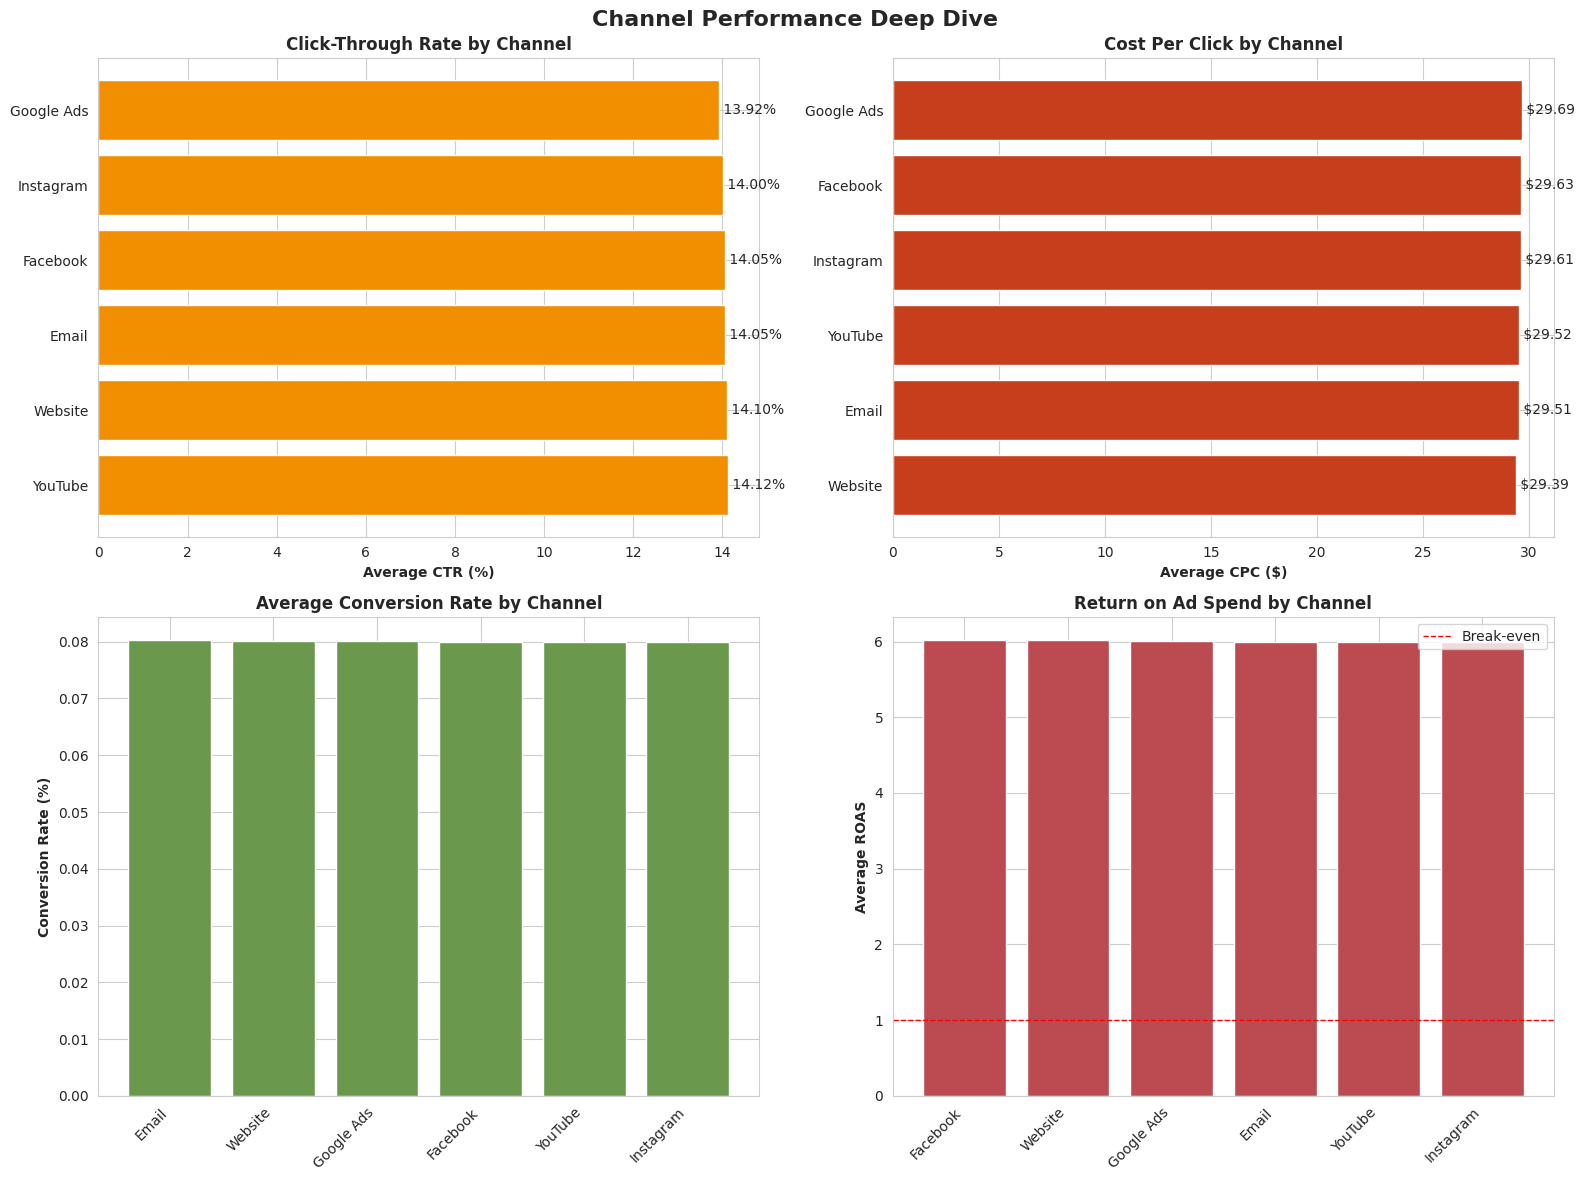

In [ ]:
# Channel Performance Analysis

fig2, axes = plt.subplots(2, 2, figsize=(16, 12))
fig2.suptitle('Channel Performance Deep Dive', fontsize=16, fontweight='bold')

# CTR by Channel
channel_ctr = market_cmp.groupby('Channel_Used')['CTR'].mean().sort_values(ascending=False)
axes[0, 0].barh(channel_ctr.index, channel_ctr.values, color='#F18F01')
axes[0, 0].set_xlabel('Average CTR (%)', fontweight='bold')
axes[0, 0].set_title('Click-Through Rate by Channel', fontweight='bold')
for i, v in enumerate(channel_ctr.values):
    axes[0, 0].text(v, i, f' {v:.2f}%', va='center')

# CPC by Channel
channel_cpc = market_cmp.groupby('Channel_Used')['CPC'].mean().sort_values()
axes[0, 1].barh(channel_cpc.index, channel_cpc.values, color='#C73E1D')
axes[0, 1].set_xlabel('Average CPC ($)', fontweight='bold')
axes[0, 1].set_title('Cost Per Click by Channel', fontweight='bold')
for i, v in enumerate(channel_cpc.values):
    axes[0, 1].text(v, i, f' ${v:.2f}', va='center')

# Conversion Rate by Channel
channel_conv = market_cmp.groupby('Channel_Used')['Conversion_Rate'].mean().sort_values(ascending=False)
axes[1, 0].bar(range(len(channel_conv)), channel_conv.values, color='#6A994E')
axes[1, 0].set_xticks(range(len(channel_conv)))
axes[1, 0].set_xticklabels(channel_conv.index, rotation=45, ha='right')
axes[1, 0].set_ylabel('Conversion Rate (%)', fontweight='bold')
axes[1, 0].set_title('Average Conversion Rate by Channel', fontweight='bold')

# ROAS by Channel
channel_roas = market_cmp.groupby('Channel_Used')['ROAS'].mean().sort_values(ascending=False)
axes[1, 1].bar(range(len(channel_roas)), channel_roas.values, color='#BC4B51')
axes[1, 1].set_xticks(range(len(channel_roas)))
axes[1, 1].set_xticklabels(channel_roas.index, rotation=45, ha='right')
axes[1, 1].set_ylabel('Average ROAS', fontweight='bold')
axes[1, 1].set_title('Return on Ad Spend by Channel', fontweight='bold')
axes[1, 1].axhline(y=1, color='red', linestyle='--', linewidth=1, label='Break-even')
axes[1, 1].legend()

plt.tight_layout()


**CUSTOMER SEGMENT ANALYSIS**

In [ ]:
# By Customer Segment
segment_performance = market_cmp.groupby('Customer_Segment').agg({
    'Revenue': 'sum',
    'Profit': 'sum',
    'ROI': 'mean',
    'Conversion_Rate': 'mean'
}).round(2).sort_values('Revenue', ascending=False)

print("\nPerformance by Customer Segment:")
print(segment_performance.to_string())




Performance by Customer Segment:
                          Revenue        Profit  ROI  Conversion_Rate
Customer_Segment                                                     
Foodies              3.027576e+09  2.523962e+09  5.0             0.08
Tech Enthusiasts     3.011209e+09  2.510063e+09  5.0             0.08
Outdoor Adventurers  3.001852e+09  2.501349e+09  5.0             0.08
Health & Wellness    2.995997e+09  2.497220e+09  5.0             0.08
Fashionistas         2.981999e+09  2.485087e+09  5.0             0.08


In [ ]:
# By Age Group
age_performance = market_cmp.groupby('Age_Group').agg({
    'Revenue': 'sum',
    'Conversion_Rate': 'mean',
    'CTR': 'mean'
}).round(2).sort_values('Revenue', ascending=False)

print("\nPerformance by Age Group:")
print(age_performance.to_string())


Performance by Age Group:
                Revenue  Conversion_Rate    CTR
Age_Group                                      
25-34      6.009307e+09             0.08  14.06
18-24      3.018166e+09             0.08  14.05
All Ages   3.006743e+09             0.08  13.98
35-44      2.984416e+09             0.08  14.06


In [ ]:
# By Gender
gender_performance = market_cmp.groupby('Gender').agg({
    'Revenue': 'sum',
    'Conversion_Rate': 'mean',
    'Engagement_Score': 'mean'
}).round(2)

print("\nPerformance by Gender:")
print(gender_performance.to_string())


Performance by Gender:
             Revenue  Conversion_Rate  Engagement_Score
Gender                                                 
All     3.006743e+09             0.08              5.49
Men     6.026335e+09             0.08              5.50
Women   5.985554e+09             0.08              5.49


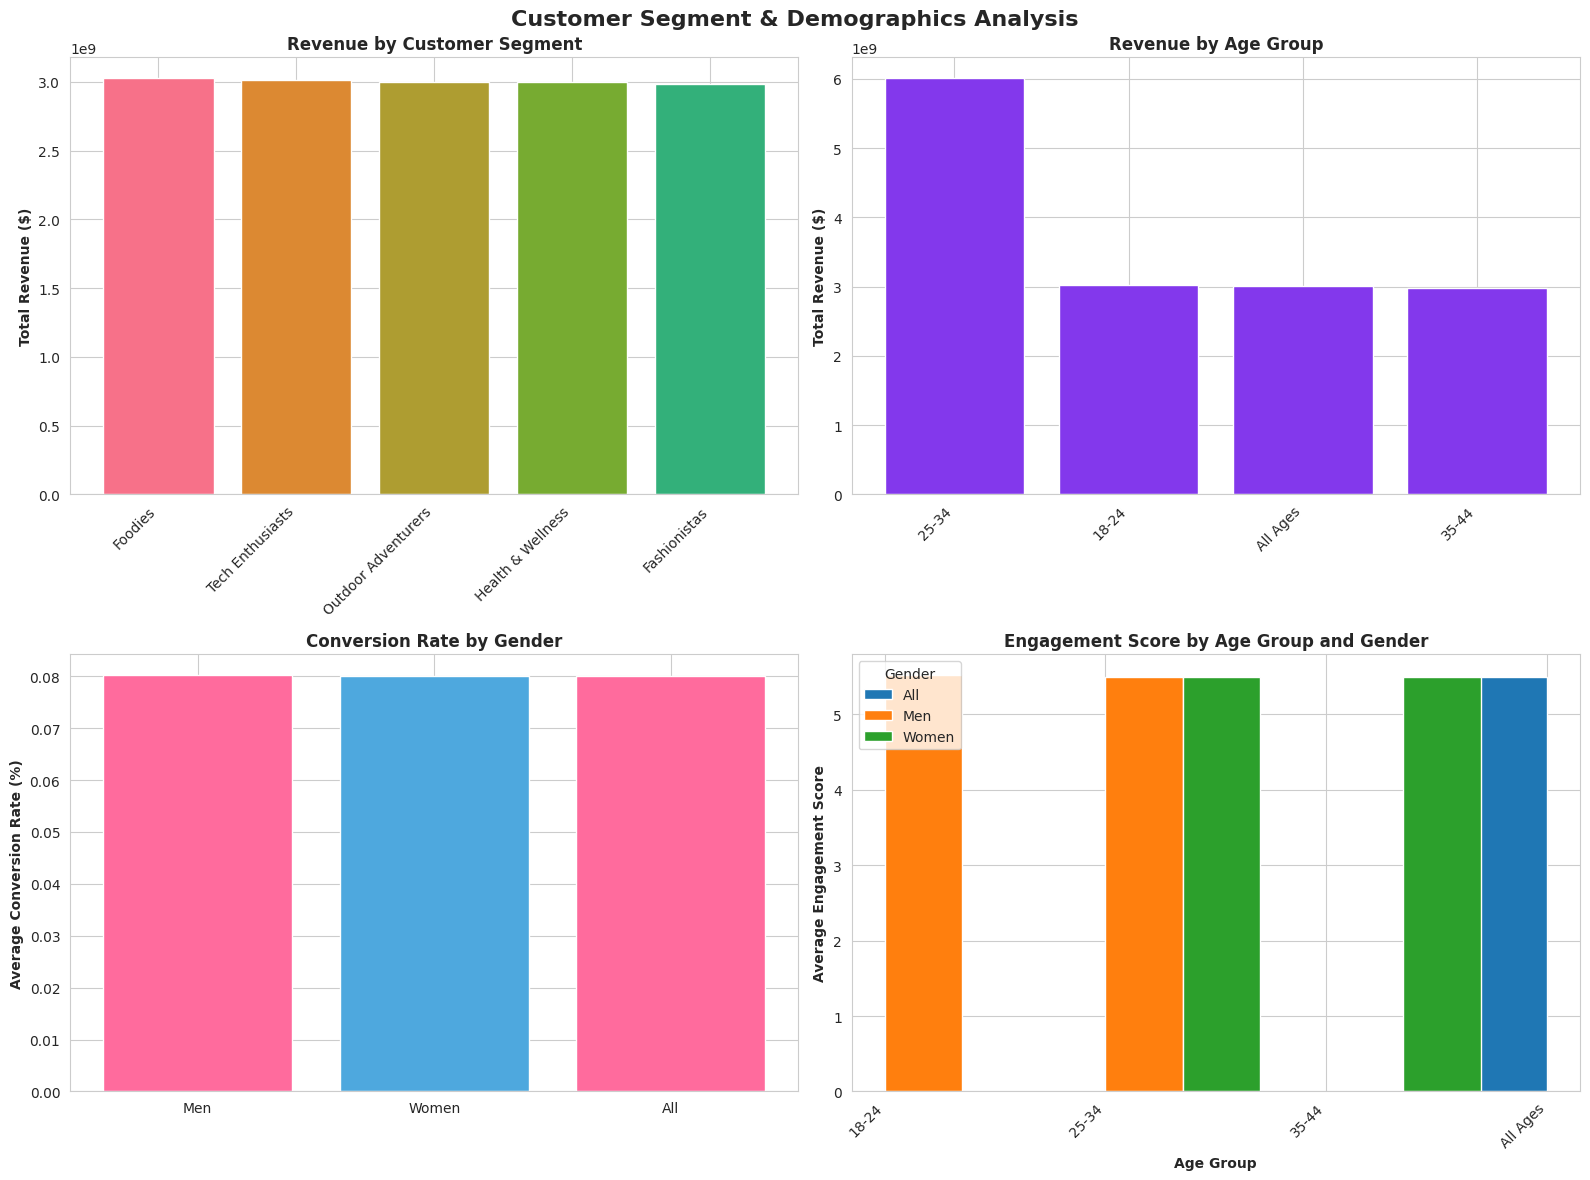

In [ ]:
# Customer Segment & Demographics

fig3, axes = plt.subplots(2, 2, figsize=(16, 12))
fig3.suptitle('Customer Segment & Demographics Analysis', fontsize=16, fontweight='bold')

# Revenue by Customer Segment
segment_rev = market_cmp.groupby('Customer_Segment')['Revenue'].sum().sort_values(ascending=False)
axes[0, 0].bar(range(len(segment_rev)), segment_rev.values, color=colors[:len(segment_rev)])
axes[0, 0].set_xticks(range(len(segment_rev)))
axes[0, 0].set_xticklabels(segment_rev.index, rotation=45, ha='right')
axes[0, 0].set_ylabel('Total Revenue ($)', fontweight='bold')
axes[0, 0].set_title('Revenue by Customer Segment', fontweight='bold')

# Revenue by Age Group
age_rev = market_cmp.groupby('Age_Group')['Revenue'].sum().sort_values(ascending=False)
axes[0, 1].bar(range(len(age_rev)), age_rev.values, color='#8338EC')
axes[0, 1].set_xticks(range(len(age_rev)))
axes[0, 1].set_xticklabels(age_rev.index, rotation=45, ha='right')
axes[0, 1].set_ylabel('Total Revenue ($)', fontweight='bold')
axes[0, 1].set_title('Revenue by Age Group', fontweight='bold')

# Conversion Rate by Gender
gender_conv = market_cmp.groupby('Gender')['Conversion_Rate'].mean().sort_values(ascending=False)
axes[1, 0].bar(range(len(gender_conv)), gender_conv.values, color=['#FF6B9D', '#4EA8DE'])
axes[1, 0].set_xticks(range(len(gender_conv)))
axes[1, 0].set_xticklabels(gender_conv.index)
axes[1, 0].set_ylabel('Average Conversion Rate (%)', fontweight='bold')
axes[1, 0].set_title('Conversion Rate by Gender', fontweight='bold')

# Engagement Score by Age Group and Gender
pivot_engagement = market_cmp.pivot_table(values='Engagement_Score',
                                   index='Age_Group',
                                   columns='Gender',
                                   aggfunc='mean')
x = np.arange(len(pivot_engagement.index))
width = 0.35
genders = pivot_engagement.columns
for i, gender in enumerate(genders):
    axes[1, 1].bar(x + i*width, pivot_engagement[gender], width, label=gender)
axes[1, 1].set_xlabel('Age Group', fontweight='bold')
axes[1, 1].set_ylabel('Average Engagement Score', fontweight='bold')
axes[1, 1].set_title('Engagement Score by Age Group and Gender', fontweight='bold')
axes[1, 1].set_xticks(x + width/2)
axes[1, 1].set_xticklabels(pivot_engagement.index, rotation=45, ha='right')
axes[1, 1].legend(title='Gender')

plt.tight_layout()


**TEMPORAL ANALYSIS**

In [ ]:
# Extract date components
market_cmp['Year'] = market_cmp['Date'].dt.year
market_cmp['Month'] = market_cmp['Date'].dt.month
market_cmp['Month_Name'] = market_cmp['Date'].dt.month_name()
market_cmp['Quarter'] = market_cmp['Date'].dt.quarter
market_cmp['Day_of_Week'] = market_cmp['Date'].dt.day_name()

# Monthly trends
monthly_trends = market_cmp.groupby('Month_Name').agg({
    'Revenue': 'sum',
    'ROI': 'mean',
    'Clicks': 'sum'
}).round(2)

print("\nMonthly Performance Trends:")
print(monthly_trends.to_string())


Monthly Performance Trends:
                 Revenue   ROI   Clicks
Month_Name                             
April       1.232186e+09  4.99  8992709
August      1.280370e+09  5.00  9308212
December    1.276154e+09  5.00  9293253
February    1.150137e+09  5.01  8433037
January     1.277022e+09  5.01  9349618
July        1.270166e+09  4.98  9347146
June        1.229120e+09  4.99  9046697
March       1.269461e+09  4.98  9367374
May         1.274748e+09  5.02  9335696
November    1.233987e+09  5.00  9029761
October     1.280674e+09  5.02  9384834
September   1.244607e+09  5.03  9069330


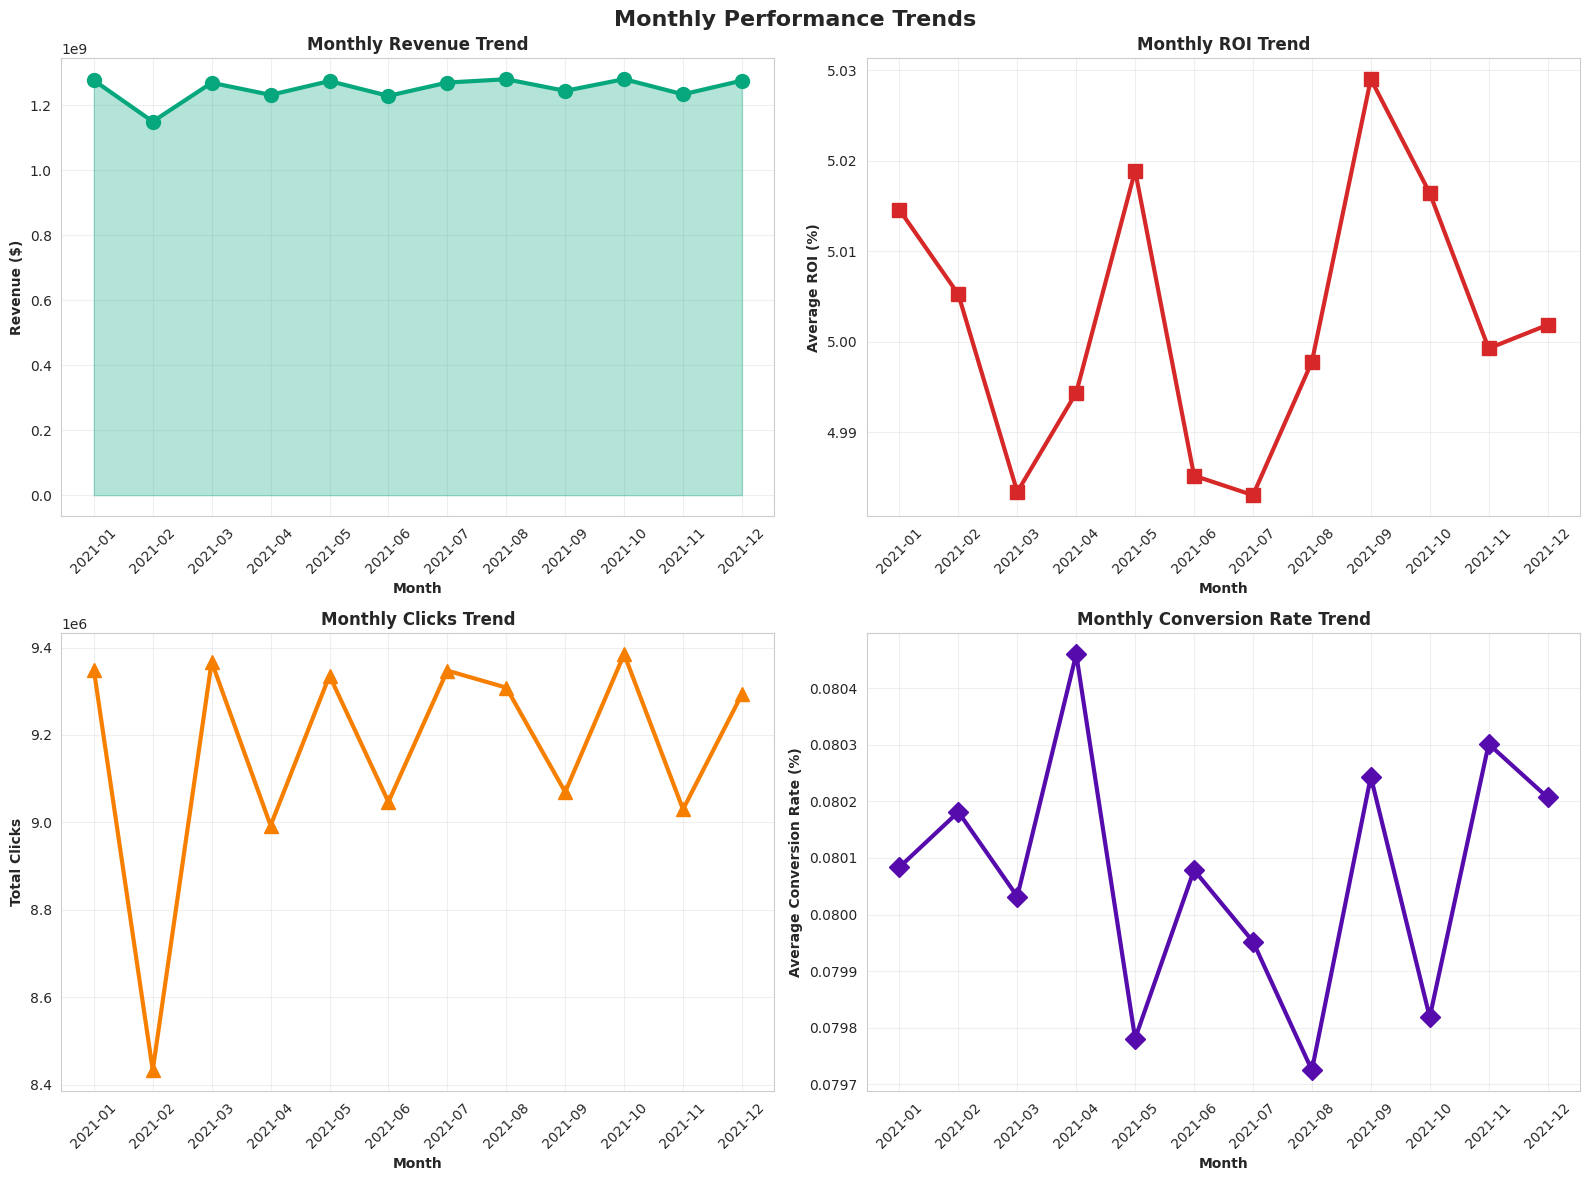

In [ ]:
# Monthly Performance Trends

fig10, axes = plt.subplots(2, 2, figsize=(16, 12))
fig10.suptitle('Monthly Performance Trends', fontsize=16, fontweight='bold')

# Revenue Trend
monthly_revenue = market_cmp.groupby(market_cmp['Date'].dt.to_period('M'))['Revenue'].sum()
axes[0, 0].plot(monthly_revenue.index.astype(str), monthly_revenue.values,
                marker='o', linewidth=3, markersize=10, color='#06A77D')
axes[0, 0].fill_between(range(len(monthly_revenue)), monthly_revenue.values, alpha=0.3, color='#06A77D')
axes[0, 0].set_xlabel('Month', fontweight='bold')
axes[0, 0].set_ylabel('Revenue ($)', fontweight='bold')
axes[0, 0].set_title('Monthly Revenue Trend', fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3)

# ROI Trend
monthly_roi = market_cmp.groupby(market_cmp['Date'].dt.to_period('M'))['ROI'].mean()
axes[0, 1].plot(monthly_roi.index.astype(str), monthly_roi.values,
                marker='s', linewidth=3, markersize=10, color='#D62828')
axes[0, 1].set_xlabel('Month', fontweight='bold')
axes[0, 1].set_ylabel('Average ROI (%)', fontweight='bold')
axes[0, 1].set_title('Monthly ROI Trend', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3)

# Clicks Trend
monthly_clicks = market_cmp.groupby(market_cmp['Date'].dt.to_period('M'))['Clicks'].sum()
axes[1, 0].plot(monthly_clicks.index.astype(str), monthly_clicks.values,
                marker='^', linewidth=3, markersize=10, color='#F77F00')
axes[1, 0].set_xlabel('Month', fontweight='bold')
axes[1, 0].set_ylabel('Total Clicks', fontweight='bold')
axes[1, 0].set_title('Monthly Clicks Trend', fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3)

# Conversion Rate Trend
monthly_conv = market_cmp.groupby(market_cmp['Date'].dt.to_period('M'))['Conversion_Rate'].mean()
axes[1, 1].plot(monthly_conv.index.astype(str), monthly_conv.values,
                marker='D', linewidth=3, markersize=10, color='#560BAD')
axes[1, 1].set_xlabel('Month', fontweight='bold')
axes[1, 1].set_ylabel('Average Conversion Rate (%)', fontweight='bold')
axes[1, 1].set_title('Monthly Conversion Rate Trend', fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()

**COMPANY PERFORMANCE**

In [ ]:
company_performance = market_cmp.groupby('Company').agg({
    'Revenue': 'sum',
    'Profit': 'sum',
    'ROI': 'mean',
    'ROAS': 'mean',
    'Acquisition_Cost': 'sum',
    'Campaign_ID': 'count'
}).round(2).sort_values('Revenue', ascending=False)

company_performance.columns = ['Total_Revenue', 'Total_Profit', 'Avg_ROI',
                                'Avg_ROAS', 'Total_Spend', 'Num_Campaigns']

print("\nCompany Performance Metrics:")
print(company_performance.to_string())


Company Performance Metrics:
                     Total_Revenue  Total_Profit  Avg_ROI  Avg_ROAS  Total_Spend  Num_Campaigns
Company                                                                                        
TechCorp              3.024611e+09  2.521257e+09     5.01      6.01    503353613          40238
Alpha Innovations     3.011679e+09  2.510497e+09     5.01      6.01    501182021          40051
DataTech Solutions    3.004858e+09  2.504555e+09     5.01      6.01    500302629          40014
NexGen Systems        2.995155e+09  2.495458e+09     4.99      5.99    499696506          39991
Innovate Industries   2.982330e+09  2.485914e+09     5.00      6.00    496416112          39711


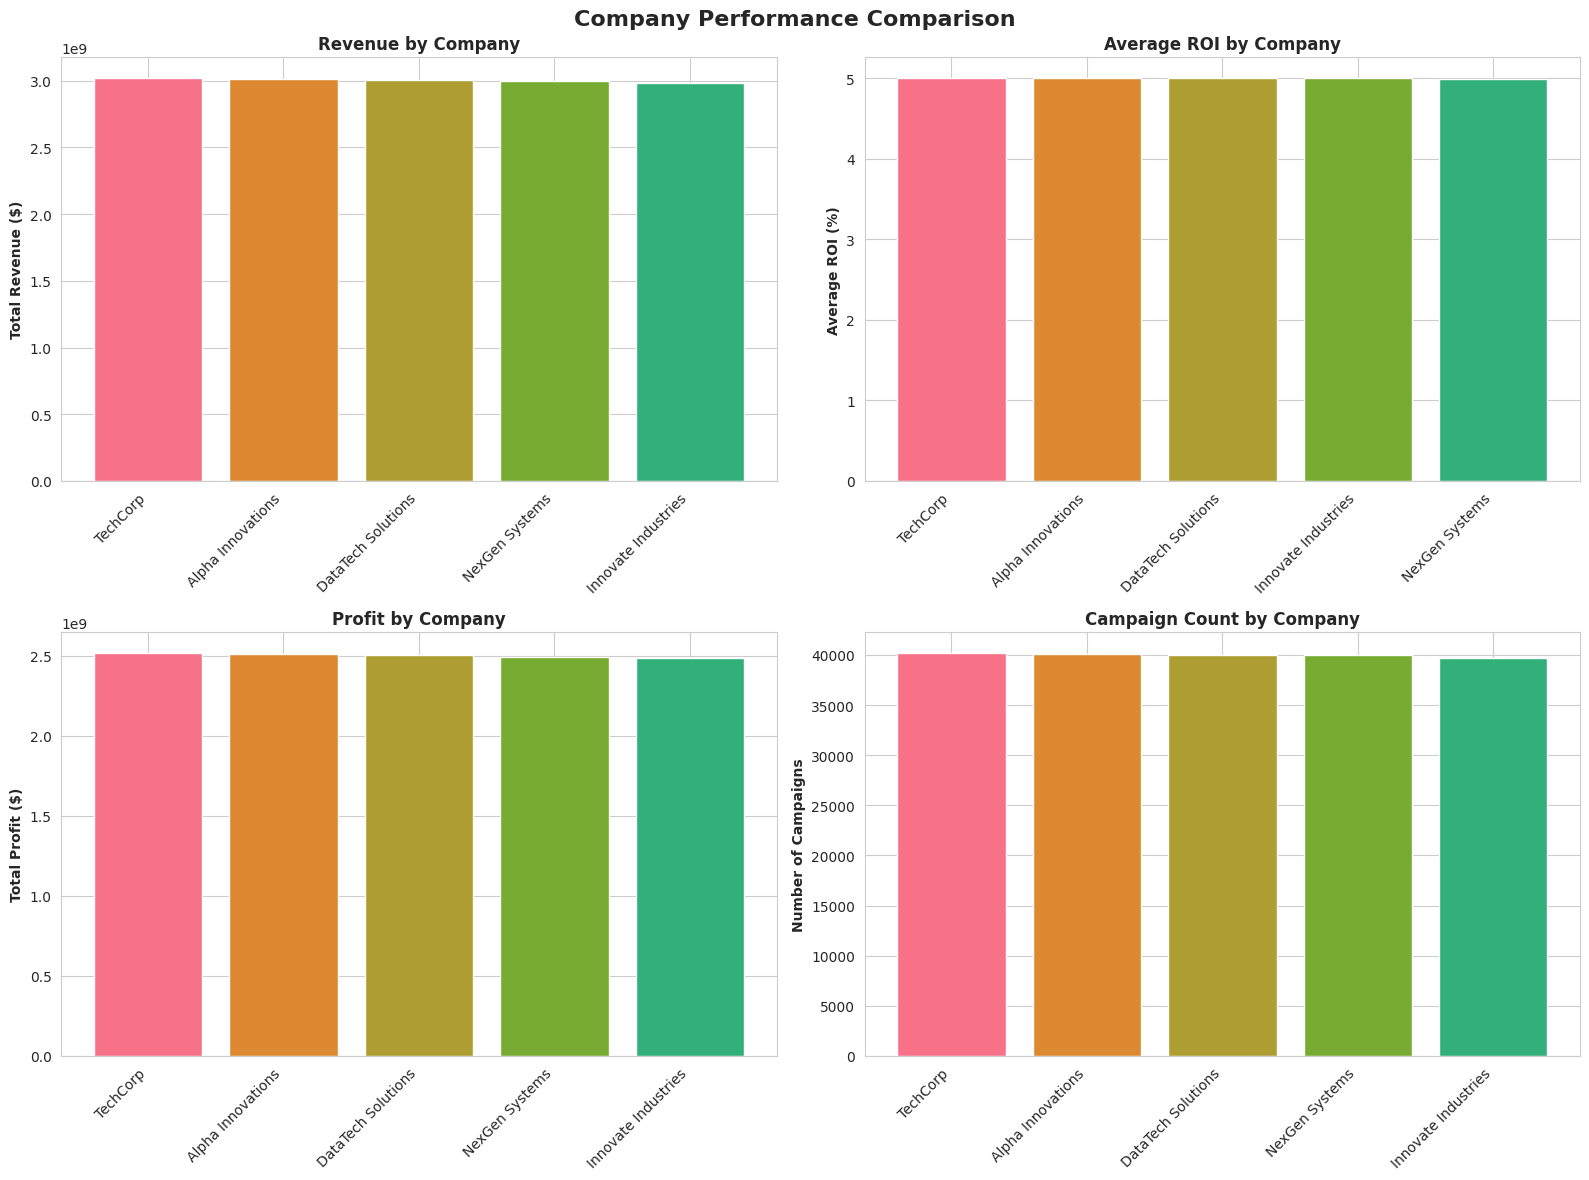

In [ ]:
# Company Performance Comparison

fig8, axes = plt.subplots(2, 2, figsize=(16, 12))
fig8.suptitle('Company Performance Comparison', fontsize=16, fontweight='bold')

# Revenue by Company
company_rev = market_cmp.groupby('Company')['Revenue'].sum().sort_values(ascending=False)
axes[0, 0].bar(range(len(company_rev)), company_rev.values, color=colors[:len(company_rev)])
axes[0, 0].set_xticks(range(len(company_rev)))
axes[0, 0].set_xticklabels(company_rev.index, rotation=45, ha='right')
axes[0, 0].set_ylabel('Total Revenue ($)', fontweight='bold')
axes[0, 0].set_title('Revenue by Company', fontweight='bold')

# ROI by Company
company_roi = market_cmp.groupby('Company')['ROI'].mean().sort_values(ascending=False)
axes[0, 1].bar(range(len(company_roi)), company_roi.values, color=colors[:len(company_roi)])
axes[0, 1].set_xticks(range(len(company_roi)))
axes[0, 1].set_xticklabels(company_roi.index, rotation=45, ha='right')
axes[0, 1].set_ylabel('Average ROI (%)', fontweight='bold')
axes[0, 1].set_title('Average ROI by Company', fontweight='bold')

# Profit by Company
company_profit = market_cmp.groupby('Company')['Profit'].sum().sort_values(ascending=False)
axes[1, 0].bar(range(len(company_profit)), company_profit.values, color=colors[:len(company_profit)])
axes[1, 0].set_xticks(range(len(company_profit)))
axes[1, 0].set_xticklabels(company_profit.index, rotation=45, ha='right')
axes[1, 0].set_ylabel('Total Profit ($)', fontweight='bold')
axes[1, 0].set_title('Profit by Company', fontweight='bold')

# Number of Campaigns by Company
company_campaigns = market_cmp.groupby('Company')['Campaign_ID'].count().sort_values(ascending=False)
axes[1, 1].bar(range(len(company_campaigns)), company_campaigns.values, color=colors[:len(company_campaigns)])
axes[1, 1].set_xticks(range(len(company_campaigns)))
axes[1, 1].set_xticklabels(company_campaigns.index, rotation=45, ha='right')
axes[1, 1].set_ylabel('Number of Campaigns', fontweight='bold')
axes[1, 1].set_title('Campaign Count by Company', fontweight='bold')

plt.tight_layout()



**CORRELATION ANALYSIS**


Campaign Type Performance Matrix:
                Revenue   ROI    CTR    CPC  Conversion_Rate  ROAS  \
Campaign_Type                                                        
Display        75149.18  5.01  14.13  29.50             0.08  6.01   
Email          74973.60  4.99  13.95  29.54             0.08  5.99   
Influencer     75216.36  5.01  14.03  29.64             0.08  6.01   
Search         75118.05  5.01  13.99  29.58             0.08  6.01   
Social Media   74997.82  4.99  14.10  29.54             0.08  5.99   

               Engagement_Score  Profit_Margin  
Campaign_Type                                   
Display                    5.51          81.71  
Email                      5.50          81.67  
Influencer                 5.48          81.71  
Search                     5.49          81.70  
Social Media               5.50          81.66  


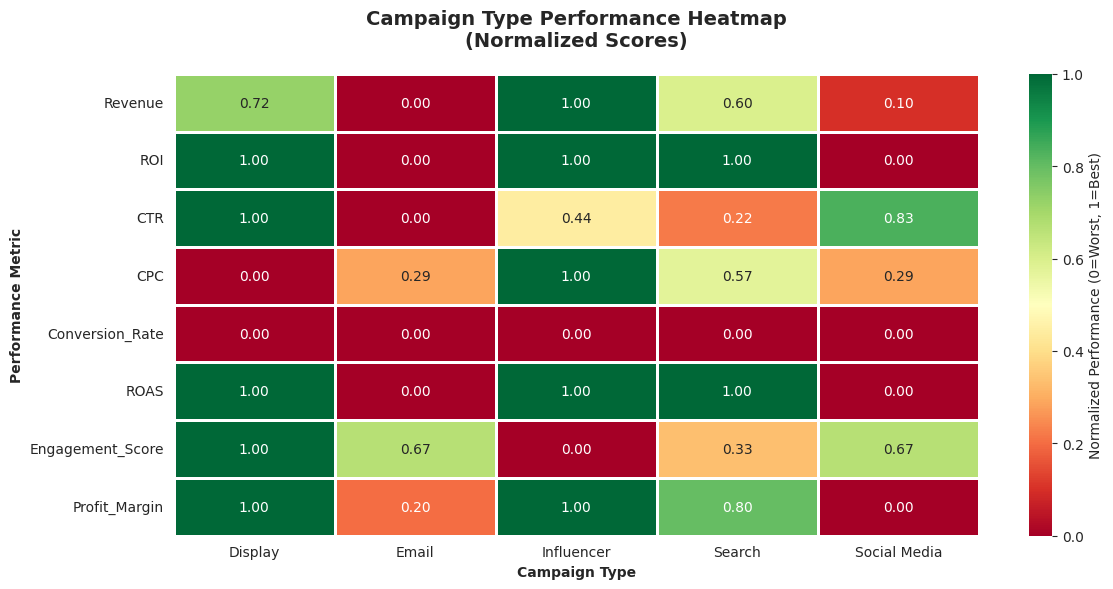

In [ ]:

# ANALYSIS 1: CAMPAIGN TYPE vs METRICS
# Which campaign types perform best on key metrics?

# Aggregate by Campaign Type
campaign_metrics = market_cmp.groupby('Campaign_Type').agg({
    'Revenue': 'mean',
    'ROI': 'mean',
    'CTR': 'mean',
    'CPC': 'mean',
    'Conversion_Rate': 'mean',
    'ROAS': 'mean',
    'Engagement_Score': 'mean',
    'Profit_Margin': 'mean'
}).round(2)

print("\nCampaign Type Performance Matrix:")
print(campaign_metrics)

# Normalize for heatmap (0-1 scale)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
campaign_metrics_normalized = pd.DataFrame(
    scaler.fit_transform(campaign_metrics),
    columns=campaign_metrics.columns,
    index=campaign_metrics.index
)

# Visualization 1: Campaign Type Heatmap
fig1, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(campaign_metrics_normalized.T, annot=True, fmt='.2f', cmap='RdYlGn',
            cbar_kws={'label': 'Normalized Performance (0=Worst, 1=Best)'},
            linewidths=1, ax=ax)
ax.set_title('Campaign Type Performance Heatmap\n(Normalized Scores)',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Campaign Type', fontweight='bold')
ax.set_ylabel('Performance Metric', fontweight='bold')
plt.tight_layout()



Channel Performance Matrix:
               Revenue   ROI    CTR    CPC  Conversion_Rate  ROAS  \
Channel_Used                                                        
Email         75140.46  5.00  14.05  29.51             0.08  6.00   
Facebook      75398.62  5.02  14.05  29.63             0.08  6.02   
Google Ads    75266.14  5.00  13.92  29.69             0.08  6.00   
Instagram     74781.43  4.99  14.00  29.61             0.08  5.99   
Website       75063.98  5.01  14.10  29.39             0.08  6.01   
YouTube       74901.77  4.99  14.12  29.52             0.08  5.99   

              Engagement_Score  Profit_Margin  
Channel_Used                                   
Email                     5.49          81.66  
Facebook                  5.50          81.73  
Google Ads                5.49          81.70  
Instagram                 5.49          81.64  
Website                   5.51          81.75  
YouTube                   5.48          81.67  


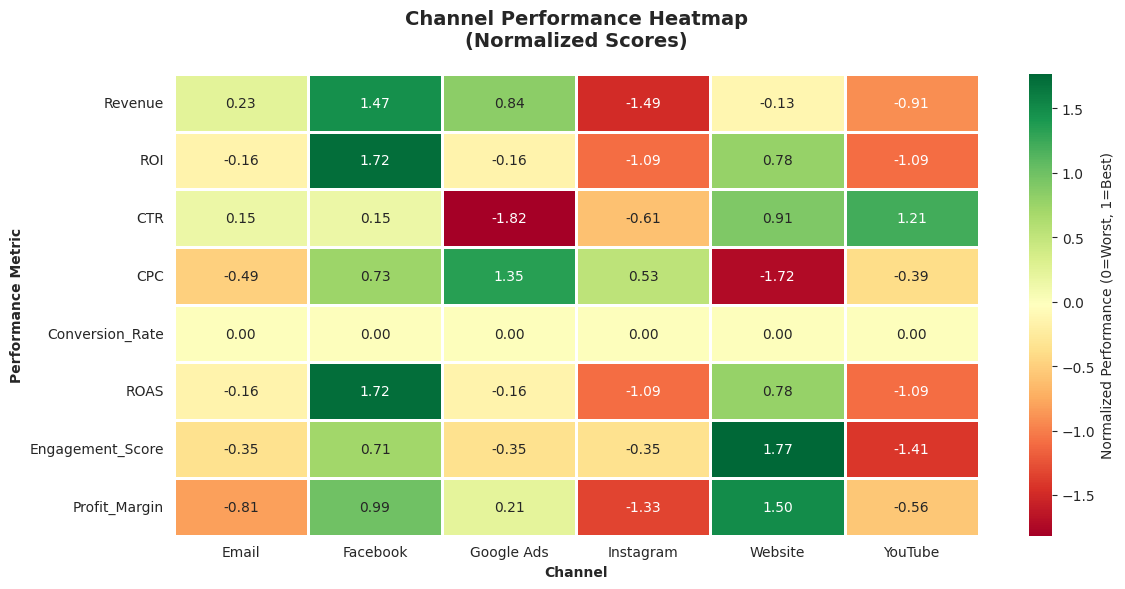

In [ ]:
# CHANNEL vs METRICS
# Which channels deliver the best results?

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Aggregate by Channel
channel_metrics = market_cmp.groupby('Channel_Used').agg({
    'Revenue': 'mean',
    'ROI': 'mean',
    'CTR': 'mean',
    'CPC': 'mean',
    'Conversion_Rate': 'mean',
    'ROAS': 'mean',
    'Engagement_Score': 'mean',
    'Profit_Margin': 'mean'
}).round(2)

print("\nChannel Performance Matrix:")
print(channel_metrics)

# Normalize
channel_metrics_normalized = pd.DataFrame(
    scaler.fit_transform(channel_metrics),
    columns=channel_metrics.columns,
    index=channel_metrics.index
)

# Visualization 2: Channel Heatmap
fig2, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(channel_metrics_normalized.T, annot=True, fmt='.2f', cmap='RdYlGn',
            cbar_kws={'label': 'Normalized Performance (0=Worst, 1=Best)'},
            linewidths=1, ax=ax)
ax.set_title('Channel Performance Heatmap\n(Normalized Scores)',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Channel', fontweight='bold')
ax.set_ylabel('Performance Metric', fontweight='bold')
plt.tight_layout()



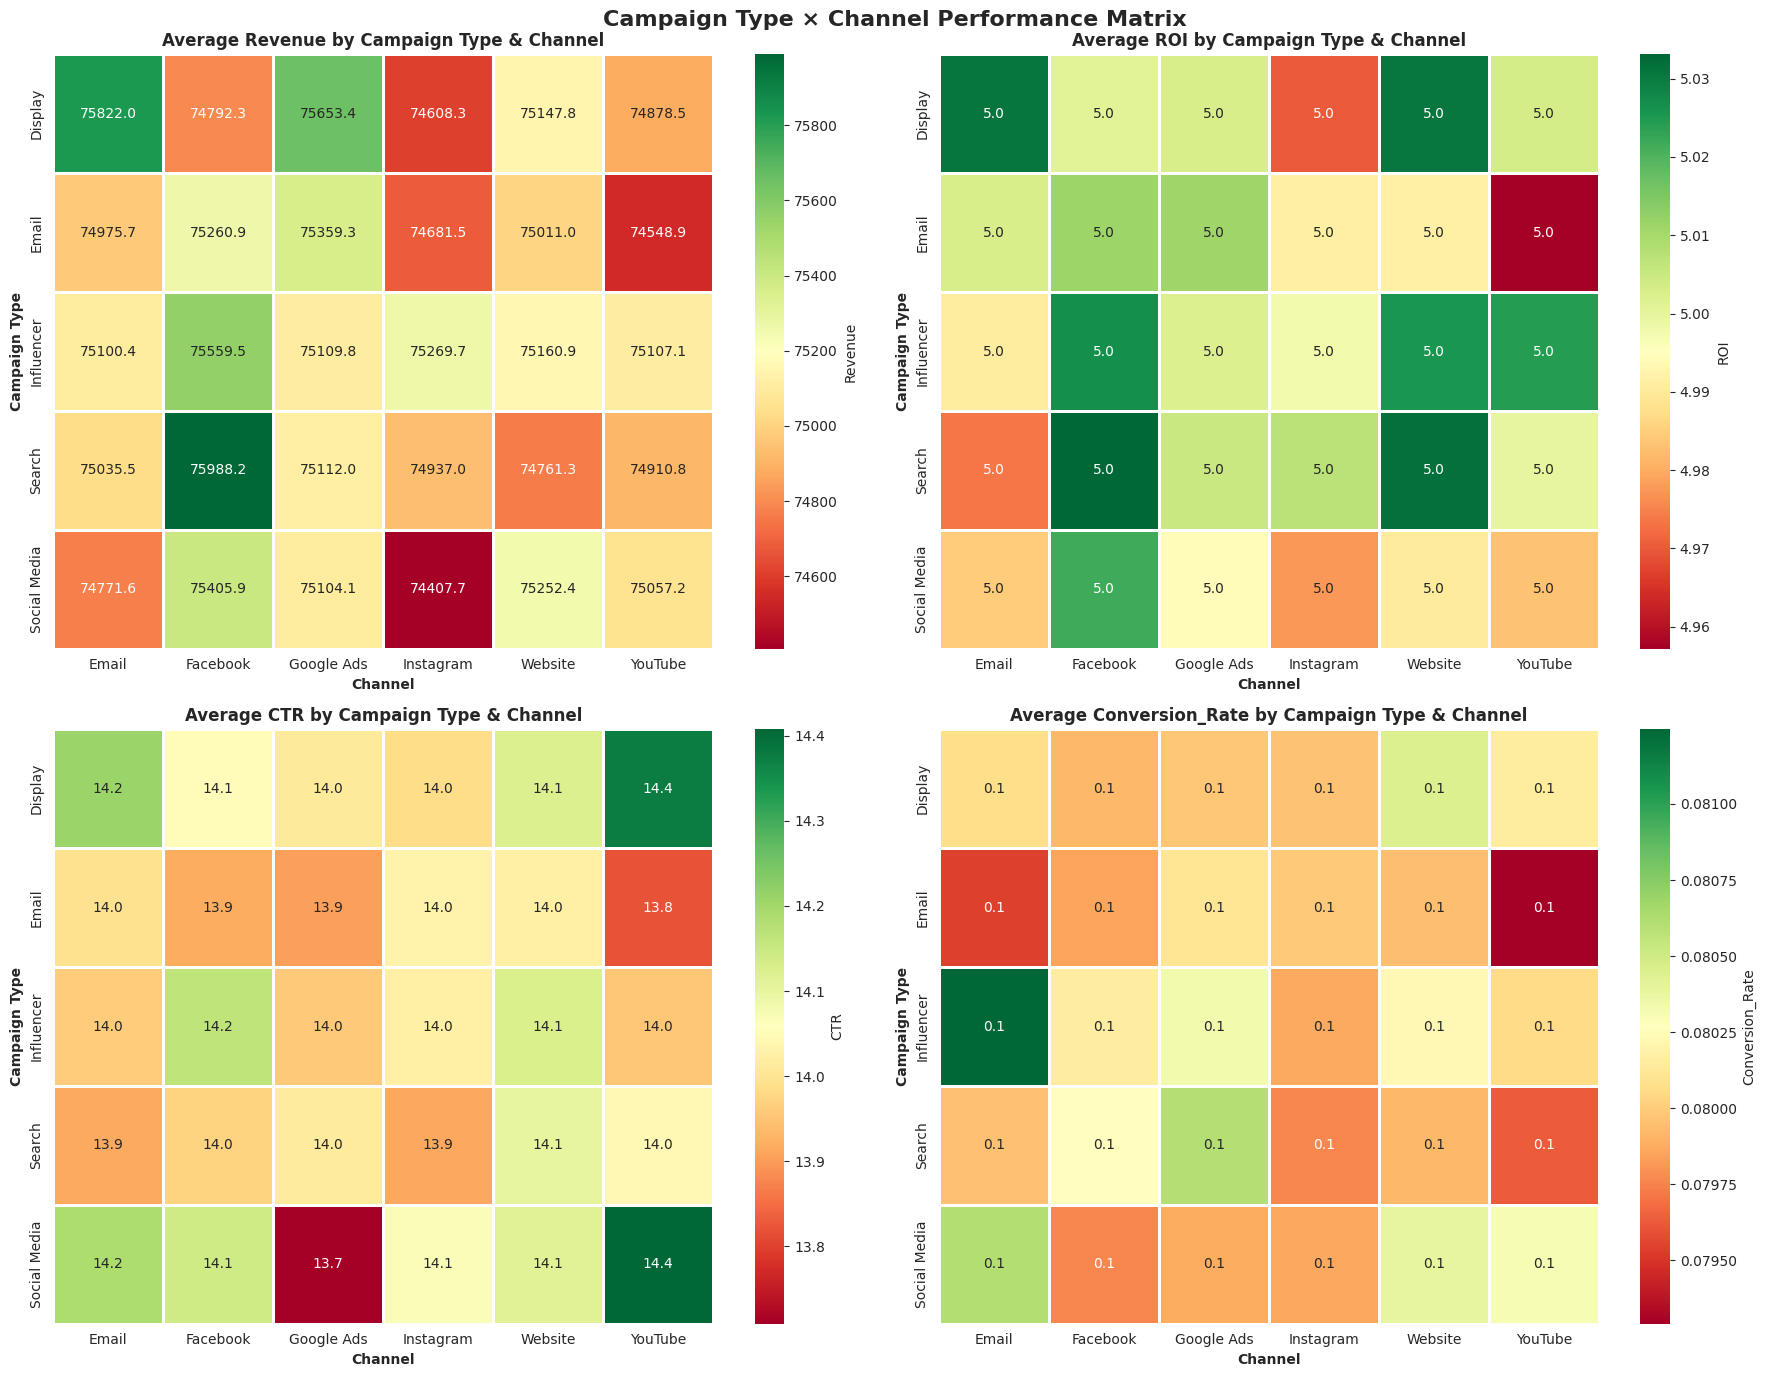

In [ ]:
# CAMPAIGN TYPE x CHANNEL
# Best Campaign Type + Channel combinations

# Create pivot tables for key metrics
metrics_to_analyze = ['Revenue', 'ROI', 'CTR', 'Conversion_Rate']

fig3, axes = plt.subplots(2, 2, figsize=(18, 14))
fig3.suptitle('Campaign Type × Channel Performance Matrix', fontsize=16, fontweight='bold')

for idx, metric in enumerate(metrics_to_analyze):
    row = idx // 2
    col = idx % 2

    # Create pivot table
    pivot = market_cmp.pivot_table(values=metric,
                           index='Campaign_Type',
                           columns='Channel_Used',
                           aggfunc='mean')

    # Plot heatmap
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn',
                linewidths=1, ax=axes[row, col], cbar_kws={'label': metric})
    axes[row, col].set_title(f'Average {metric} by Campaign Type & Channel',
                             fontweight='bold')
    axes[row, col].set_xlabel('Channel', fontweight='bold')
    axes[row, col].set_ylabel('Campaign Type', fontweight='bold')

plt.tight_layout()


In [ ]:
# TOP PERFORMING COMBINATIONS

# Calculate combination scores
combination_performance = market_cmp.groupby(['Campaign_Type', 'Channel_Used']).agg({
    'Revenue': 'mean',
    'ROI': 'mean',
    'ROAS': 'mean',
    'Conversion_Rate': 'mean',
    'Campaign_ID': 'count'
}).round(2)
combination_performance.columns = ['Avg_Revenue', 'Avg_ROI', 'Avg_ROAS',
                                    'Avg_Conv_Rate', 'Num_Campaigns']

# Sort by ROI
combination_performance = combination_performance.sort_values('Avg_ROI', ascending=False)

print("\n🏆 TOP 10 CAMPAIGN TYPE + CHANNEL COMBINATIONS (by ROI):")
print(combination_performance.head(10).to_string())

print("\n⚠️ BOTTOM 10 CAMPAIGN TYPE + CHANNEL COMBINATIONS (by ROI):")
print(combination_performance.tail(10).to_string())



🏆 TOP 10 CAMPAIGN TYPE + CHANNEL COMBINATIONS (by ROI):
                            Avg_Revenue  Avg_ROI  Avg_ROAS  Avg_Conv_Rate  Num_Campaigns
Campaign_Type Channel_Used                                                              
Display       Email            75821.96     5.03      6.03           0.08           6701
              Website          75147.77     5.03      6.03           0.08           6622
Influencer    Facebook         75559.55     5.03      6.03           0.08           6548
Search        Website          74761.26     5.03      6.03           0.08           6899
              Facebook         75988.21     5.03      6.03           0.08           6488
Influencer    Website          75160.90     5.03      6.03           0.08           6650
              YouTube          75107.14     5.02      6.02           0.08           6774
Social Media  Facebook         75405.86     5.02      6.02           0.08           6566
Search        Google Ads       75112.05     5.01     

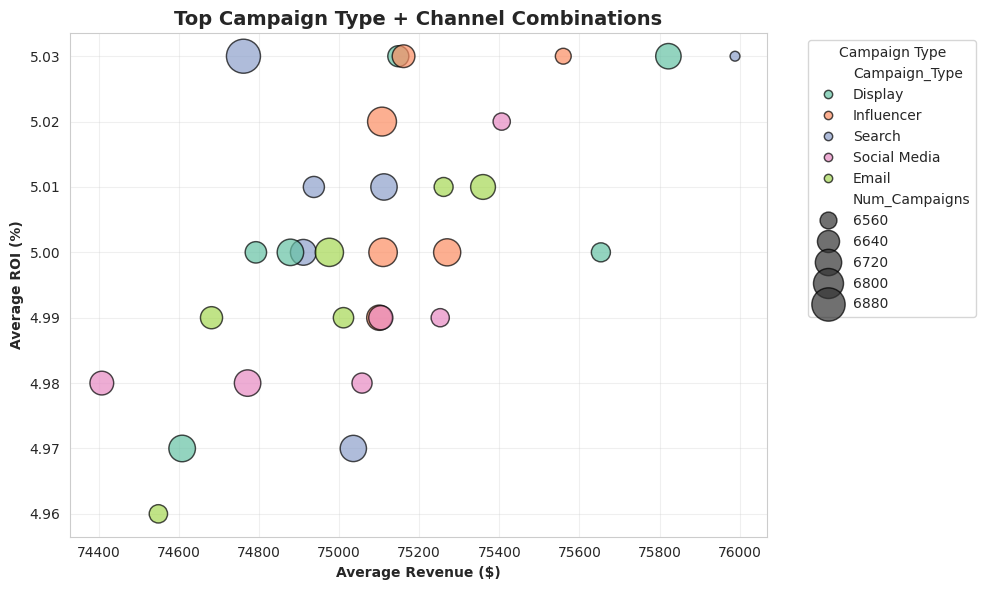

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=combination_performance.reset_index(),
    x='Avg_Revenue', y='Avg_ROI',
    size='Num_Campaigns', hue='Campaign_Type',
    sizes=(50, 600), alpha=0.7, palette='Set2', edgecolor='black'
)
plt.title('Top Campaign Type + Channel Combinations', fontsize=14, fontweight='bold')
plt.xlabel('Average Revenue ($)', fontweight='bold')
plt.ylabel('Average ROI (%)', fontweight='bold')
plt.legend(title='Campaign Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**TOP & BOTTOM PERFORMERS**

In [ ]:
# Top 10 by Revenue
print("\n🏆 TOP 10 CAMPAIGNS BY REVENUE:")
top_revenue = market_cmp.nlargest(10, 'Revenue')[['Campaign_ID', 'Company', 'Campaign_Type',
                                            'Channel_Used', 'Revenue', 'ROI', 'CTR']]
print(top_revenue.to_string(index=False))



🏆 TOP 10 CAMPAIGNS BY REVENUE:
 Campaign_ID             Company Campaign_Type Channel_Used   Revenue  ROI       CTR
       13019  DataTech Solutions    Influencer     Facebook 179438.36 7.98  7.071495
       73095            TechCorp    Influencer        Email 179346.18 7.97  6.361272
       33606  DataTech Solutions         Email        Email 179339.58 7.98  9.417510
       13708   Alpha Innovations       Display   Google Ads 179321.62 7.98  6.668131
        8281   Alpha Innovations  Social Media      YouTube 179294.68 7.98 11.063243
       72530 Innovate Industries       Display      Website 179280.00 8.00 13.506454
      163709 Innovate Industries       Display    Instagram 179179.69 7.99  8.007117
       11708 Innovate Industries       Display    Instagram 179007.32 7.98  4.759358
      172561            TechCorp        Search      Website 178760.96 7.96  6.650831
       70216 Innovate Industries    Influencer   Google Ads 178656.96 7.94  3.755523


In [ ]:
# Top 10 by ROI
print("\n🏆 TOP 10 CAMPAIGNS BY ROI:")
top_roi = market_cmp.nlargest(10, 'ROI')[['Campaign_ID', 'Company', 'Campaign_Type',
                                    'Channel_Used', 'ROI', 'Revenue', 'Profit']]
print(top_roi.to_string(index=False))


🏆 TOP 10 CAMPAIGNS BY ROI:
 Campaign_ID             Company Campaign_Type Channel_Used  ROI  Revenue   Profit
         168      NexGen Systems       Display      Website  8.0 106911.0  95032.0
         220 Innovate Industries    Influencer        Email  8.0  94824.0  84288.0
        3056      NexGen Systems        Search        Email  8.0 136170.0 121040.0
        3232   Alpha Innovations       Display    Instagram  8.0 114831.0 102072.0
        5348            TechCorp  Social Media        Email  8.0 125136.0 111232.0
        5930 Innovate Industries    Influencer    Instagram  8.0 150570.0 133840.0
        8226      NexGen Systems    Influencer   Google Ads  8.0  71154.0  63248.0
        8366 Innovate Industries       Display      Website  8.0 102726.0  91312.0
        9891   Alpha Innovations       Display        Email  8.0 103581.0  92072.0
       12332            TechCorp       Display      YouTube  8.0  79164.0  70368.0


In [ ]:
# Bottom 10 by ROI
print("\n⚠️ BOTTOM 10 CAMPAIGNS BY ROI (Consider Terminating):")
bottom_roi = market_cmp.nsmallest(10, 'ROI')[['Campaign_ID', 'Company', 'Campaign_Type',
                                        'Channel_Used', 'ROI', 'Revenue', 'Acquisition_Cost']]
print(bottom_roi.to_string(index=False))


⚠️ BOTTOM 10 CAMPAIGNS BY ROI (Consider Terminating):
 Campaign_ID            Company Campaign_Type Channel_Used  ROI  Revenue  Acquisition_Cost
        1164     NexGen Systems       Display      Website  2.0  55092.0             18364
        1381  Alpha Innovations       Display    Instagram  2.0  16845.0              5615
        7600           TechCorp       Display    Instagram  2.0  51579.0             17193
        7824           TechCorp  Social Media   Google Ads  2.0  52122.0             17374
       10286  Alpha Innovations         Email     Facebook  2.0  55767.0             18589
       12211     NexGen Systems    Influencer        Email  2.0  43833.0             14611
       14202     NexGen Systems       Display      Website  2.0  36495.0             12165
       14853 DataTech Solutions       Display      YouTube  2.0  32928.0             10976
       15477     NexGen Systems    Influencer        Email  2.0  19020.0              6340
       15557  Alpha Innovations    

In [ ]:
# Negative ROI campaigns
negative_roi = market_cmp[market_cmp['ROI'] < 0]
print(f"\n🚨 CAMPAIGNS WITH NEGATIVE ROI: {len(negative_roi)} ({len(negative_roi)/len(market_cmp)*100:.1f}%)")
if len(negative_roi) > 0:
    print("   Total Loss from Negative ROI Campaigns: ${:,.2f}".format(negative_roi['Profit'].sum()))


🚨 CAMPAIGNS WITH NEGATIVE ROI: 0 (0.0%)


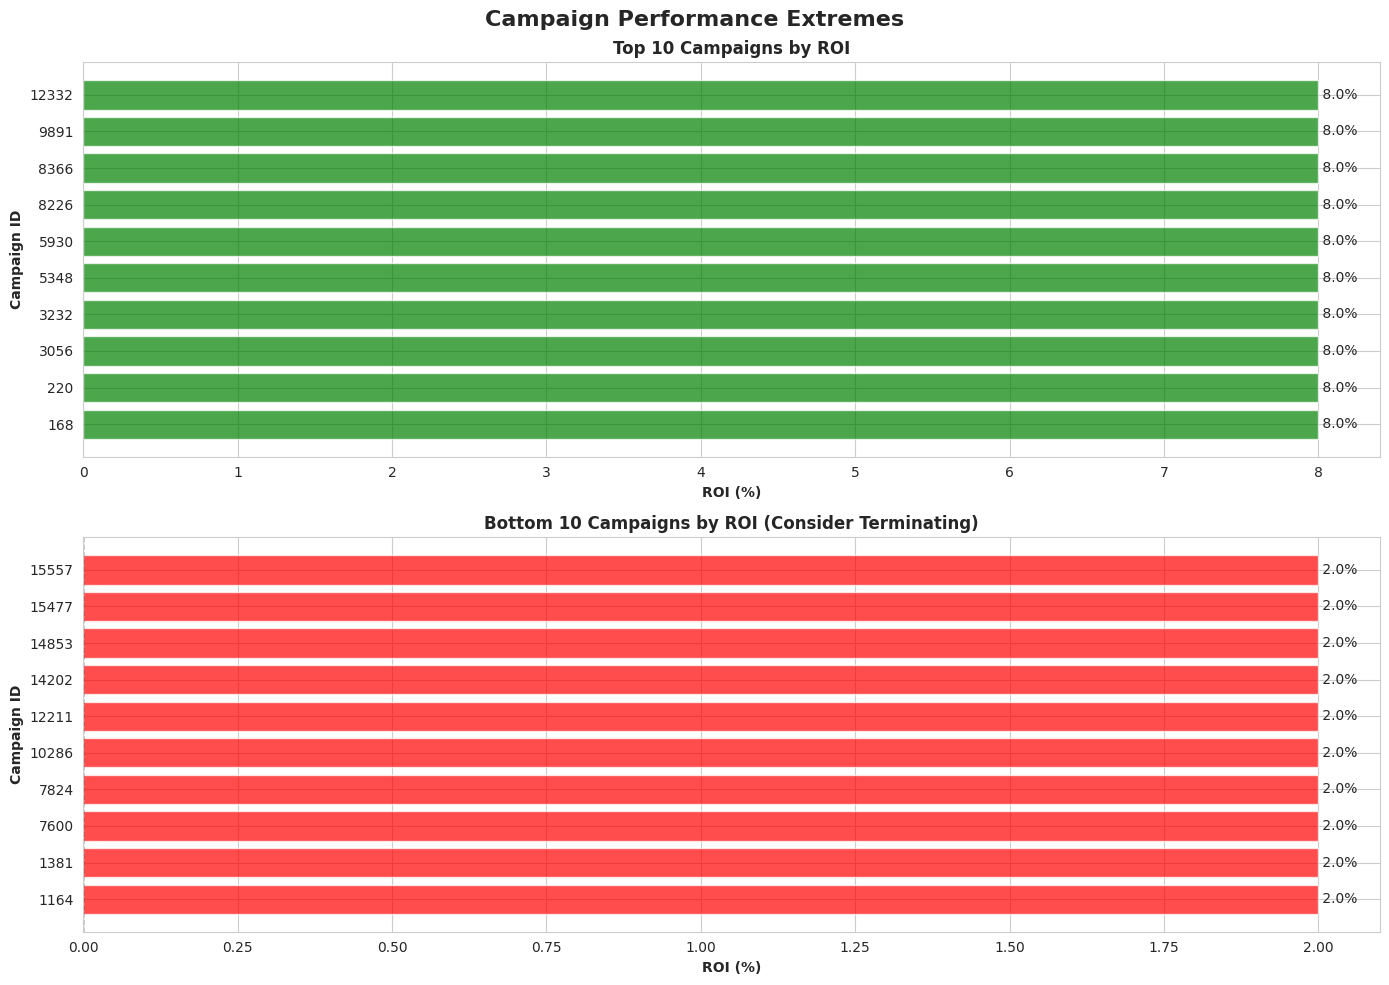

In [ ]:
# Top & Bottom Performers

fig6, axes = plt.subplots(2, 1, figsize=(14, 10))
fig6.suptitle('Campaign Performance Extremes', fontsize=16, fontweight='bold')

# Top 10 Campaigns by ROI
top_10 = market_cmp.nlargest(10, 'ROI')[['Campaign_ID', 'ROI', 'Revenue']].sort_values('ROI')
axes[0].barh(top_10['Campaign_ID'].astype(str), top_10['ROI'], color='green', alpha=0.7)
axes[0].set_xlabel('ROI (%)', fontweight='bold')
axes[0].set_ylabel('Campaign ID', fontweight='bold')
axes[0].set_title('Top 10 Campaigns by ROI', fontweight='bold')
for i, (idx, row) in enumerate(top_10.iterrows()):
    axes[0].text(row['ROI'], i, f" {row['ROI']:.1f}%", va='center')

# Bottom 10 Campaigns by ROI
bottom_10 = market_cmp.nsmallest(10, 'ROI')[['Campaign_ID', 'ROI', 'Revenue']].sort_values('ROI', ascending=False)
axes[1].barh(bottom_10['Campaign_ID'].astype(str), bottom_10['ROI'], color='red', alpha=0.7)
axes[1].set_xlabel('ROI (%)', fontweight='bold')
axes[1].set_ylabel('Campaign ID', fontweight='bold')
axes[1].set_title('Bottom 10 Campaigns by ROI (Consider Terminating)', fontweight='bold')
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=1)
for i, (idx, row) in enumerate(bottom_10.iterrows()):
    axes[1].text(row['ROI'], i, f" {row['ROI']:.1f}%", va='center')

plt.tight_layout()



**EFFICIENCY METRICS**

In [ ]:
print("\nCost Metrics Summary:")
print(f"Average Cost Per Click (CPC): ${market_cmp['CPC'].mean():.2f}")
print(f"Average Cost Per Acquisition (CPA): ${market_cmp['CPA'].mean():.2f}")
print(f"Average Revenue Per Click: ${market_cmp['Revenue_Per_Click'].mean():.2f}")
print(f"Average Profit Margin: {market_cmp['Profit_Margin'].mean():.2f}%")

# Efficiency by channel
efficiency = market_cmp.groupby('Channel_Used').agg({
    'CPC': 'mean',
    'CPA': 'mean',
    'Revenue_Per_Click': 'mean'
}).round(2).sort_values('Revenue_Per_Click', ascending=False)

print("\nEfficiency by Channel:")
print(efficiency.to_string())


Cost Metrics Summary:
Average Cost Per Click (CPC): $29.56
Average Cost Per Acquisition (CPA): $63533.51
Average Revenue Per Click: $192.34
Average Profit Margin: 81.69%

Efficiency by Channel:
                CPC       CPA  Revenue_Per_Click
Channel_Used                                    
Google Ads    29.69  64227.57             194.42
Facebook      29.63  63384.37             193.45
Instagram     29.61  63575.16             192.15
YouTube       29.52  63589.80             191.65
Email         29.51  63215.50             191.50
Website       29.39  63206.76             190.91


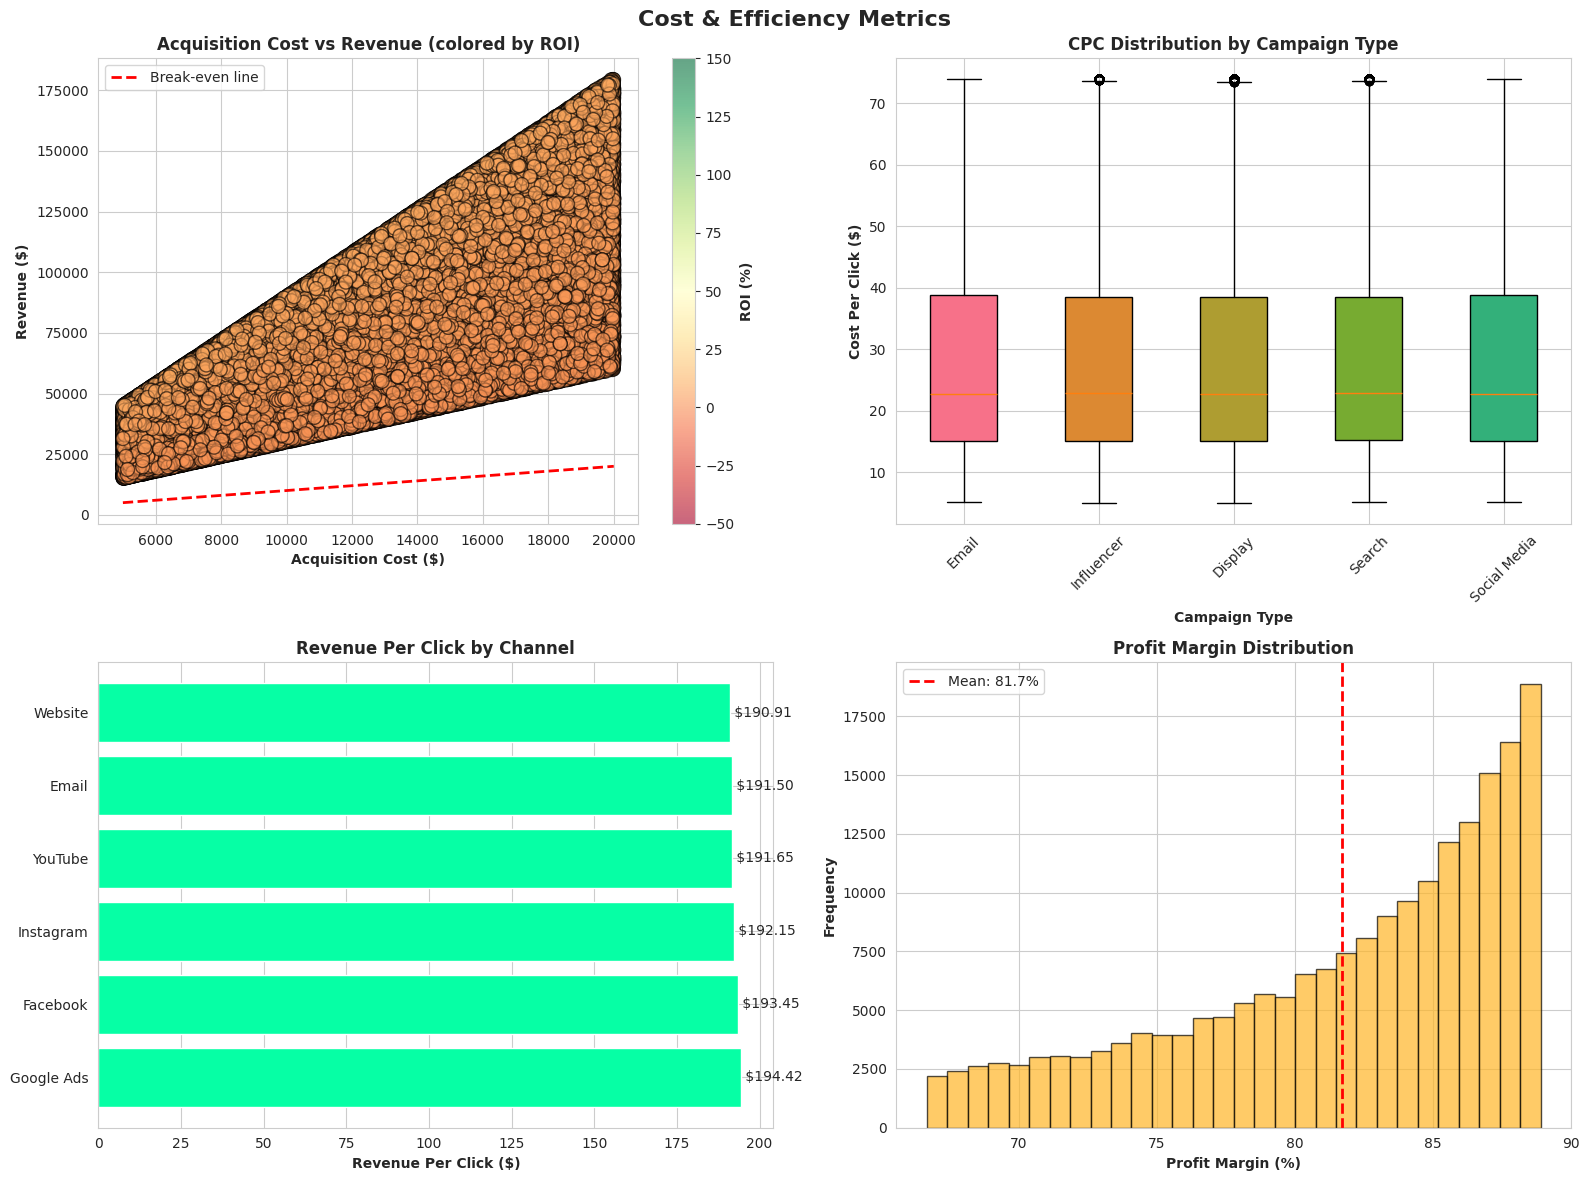

In [ ]:
# Cost & Efficiency Metrics.

fig4, axes = plt.subplots(2, 2, figsize=(16, 12))
fig4.suptitle('Cost & Efficiency Metrics', fontsize=16, fontweight='bold')

# Acquisition Cost vs Revenue Scatter
scatter = axes[0, 0].scatter(market_cmp['Acquisition_Cost'], market_cmp['Revenue'],
                             c=market_cmp['ROI'], cmap='RdYlGn', s=100, alpha=0.6,
                             edgecolors='black', vmin=-50, vmax=150)
axes[0, 0].plot([market_cmp['Acquisition_Cost'].min(), market_cmp['Acquisition_Cost'].max()],
                [market_cmp['Acquisition_Cost'].min(), market_cmp['Acquisition_Cost'].max()],
                'r--', linewidth=2, label='Break-even line')
axes[0, 0].set_xlabel('Acquisition Cost ($)', fontweight='bold')
axes[0, 0].set_ylabel('Revenue ($)', fontweight='bold')
axes[0, 0].set_title('Acquisition Cost vs Revenue (colored by ROI)', fontweight='bold')
axes[0, 0].legend()
cbar = plt.colorbar(scatter, ax=axes[0, 0])
cbar.set_label('ROI (%)', fontweight='bold')

# CPC Distribution by Campaign Type
campaign_types = market_cmp['Campaign_Type'].unique()
cpc_data = [market_cmp[market_cmp['Campaign_Type'] == ct]['CPC'].values for ct in campaign_types]
bp = axes[0, 1].boxplot(cpc_data, labels=campaign_types, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[0, 1].set_xlabel('Campaign Type', fontweight='bold')
axes[0, 1].set_ylabel('Cost Per Click ($)', fontweight='bold')
axes[0, 1].set_title('CPC Distribution by Campaign Type', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)

# Revenue Per Click by Channel
channel_rpc = market_cmp.groupby('Channel_Used')['Revenue_Per_Click'].mean().sort_values(ascending=False)
axes[1, 0].barh(channel_rpc.index, channel_rpc.values, color='#06FFA5')
axes[1, 0].set_xlabel('Revenue Per Click ($)', fontweight='bold')
axes[1, 0].set_title('Revenue Per Click by Channel', fontweight='bold')
for i, v in enumerate(channel_rpc.values):
    axes[1, 0].text(v, i, f' ${v:.2f}', va='center')

# Profit Margin Distribution
axes[1, 1].hist(market_cmp['Profit_Margin'], bins=30, color='#FFB627', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(market_cmp['Profit_Margin'].mean(), color='red', linestyle='--',
                   linewidth=2, label=f'Mean: {market_cmp["Profit_Margin"].mean():.1f}%')
axes[1, 1].set_xlabel('Profit Margin (%)', fontweight='bold')
axes[1, 1].set_ylabel('Frequency', fontweight='bold')
axes[1, 1].set_title('Profit Margin Distribution', fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()


**KEY INSIGHTS & RECOMMENDATIONS**

In [ ]:
print("\n" + "="*70)
print("📊 KEY FINDINGS:")
print("="*70)
print(f"1. Total Marketing Investment: ${market_cmp['Acquisition_Cost'].sum():,.2f}")
print(f"2. Total Revenue Generated: ${market_cmp['Revenue'].sum():,.2f}")
print(f"3. Total Profit: ${market_cmp['Profit'].sum():,.2f}")
print(f"4. Overall Marketing ROI: {market_cmp['ROI'].mean():.2f}%")
print(f"5. Best Performing Channel: {best_channel_roi} (ROI: {channel_performance.loc[best_channel_roi, 'Avg_ROI']:.2f}%)")
print(f"6. Most Profitable Customer Segment: {segment_performance.index[0]} (${segment_performance['Revenue'].iloc[0]:,.2f})")


# Find best performers
best_campaign_type = campaign_metrics['ROI'].idxmax()
best_channel = channel_metrics['ROI'].idxmax()
best_combination = combination_performance.head(1)


print("\n" + "="*70)
print("🎯 KEY STRATEGIC INSIGHTS:")
print("="*70)

print(f"\n1. BEST CAMPAIGN TYPE OVERALL:")
print(f"   {best_campaign_type}")
print(f"   Average ROI: {campaign_metrics.loc[best_campaign_type, 'ROI']:.2f}%")
print(f"   Average Revenue: ${campaign_metrics.loc[best_campaign_type, 'Revenue']:,.2f}")

print(f"\n2. BEST CHANNEL OVERALL:")
print(f"   {best_channel}")
print(f"   Average ROI: {channel_metrics.loc[best_channel, 'ROI']:.2f}%")
print(f"   Average CTR: {channel_metrics.loc[best_channel, 'CTR']:.2f}%")

print(f"\n3. BEST COMBINATION:")
best_combo_type, best_combo_channel = best_combination.index[0]
print(f"   Campaign Type: {best_combo_type}")
print(f"   Channel: {best_combo_channel}")
print(f"   Average ROI: {best_combination['Avg_ROI'].iloc[0]:.2f}%")
print(f"   Average Revenue: ${best_combination['Avg_Revenue'].iloc[0]:,.2f}")
print(f"   Number of Campaigns: {best_combination['Num_Campaigns'].iloc[0]}")

# Find underperformers
worst_combination = combination_performance.tail(1)
worst_combo_type, worst_combo_channel = worst_combination.index[0]

print(f"\n4. WORST COMBINATION (AVOID):")
print(f"   Campaign Type: {worst_combo_type}")
print(f"   Channel: {worst_combo_channel}")
print(f"   Average ROI: {worst_combination['Avg_ROI'].iloc[0]:.2f}%")

# Channel efficiency
print(f"\n5. CHANNEL EFFICIENCY RANKING:")
channel_efficiency = channel_metrics.copy()
channel_efficiency['Efficiency_Score'] = (
    channel_efficiency['ROI'] * channel_efficiency['ROAS'] / channel_efficiency['CPC']
)
channel_efficiency = channel_efficiency.sort_values('Efficiency_Score', ascending=False)
for idx, channel in enumerate(channel_efficiency.index[:5], 1):
    print(f"   {idx}. {channel} (ROI: {channel_efficiency.loc[channel, 'ROI']:.1f}%, "
          f"CPC: ${channel_efficiency.loc[channel, 'CPC']:.2f})")

# Campaign Type ROI ranking
print(f"\n6. CAMPAIGN TYPE ROI RANKING:")
campaign_roi_rank = campaign_metrics.sort_values('ROI', ascending=False)
for idx, ctype in enumerate(campaign_roi_rank.index[:5], 1):
    print(f"   {idx}. {ctype} (ROI: {campaign_roi_rank.loc[ctype, 'ROI']:.1f}%, "
          f"Conv Rate: {campaign_roi_rank.loc[ctype, 'Conversion_Rate']:.2f}%)")




📊 KEY FINDINGS:
1. Total Marketing Investment: $2,500,950,881.00
2. Total Revenue Generated: $15,018,632,372.89
3. Total Profit: $12,517,681,491.89
4. Overall Marketing ROI: 5.00%
5. Best Performing Channel: Facebook (ROI: 5.02%)
6. Most Profitable Customer Segment: Foodies ($3,027,576,339.71)

🎯 KEY STRATEGIC INSIGHTS:

1. BEST CAMPAIGN TYPE OVERALL:
   Display
   Average ROI: 5.01%
   Average Revenue: $75,149.18

2. BEST CHANNEL OVERALL:
   Facebook
   Average ROI: 5.02%
   Average CTR: 14.05%

3. BEST COMBINATION:
   Campaign Type: Display
   Channel: Email
   Average ROI: 5.03%
   Average Revenue: $75,821.96
   Number of Campaigns: 6701

4. WORST COMBINATION (AVOID):
   Campaign Type: Email
   Channel: YouTube
   Average ROI: 4.96%

5. CHANNEL EFFICIENCY RANKING:
   1. Website (ROI: 5.0%, CPC: $29.39)
   2. Facebook (ROI: 5.0%, CPC: $29.63)
   3. Email (ROI: 5.0%, CPC: $29.51)
   4. YouTube (ROI: 5.0%, CPC: $29.52)
   5. Google Ads (ROI: 5.0%, CPC: $29.69)

6. CAMPAIGN TYPE ROI RA

## 🧭 **Strategic Summary of Findings**

The marketing campaigns are **profitable and well-scaled**, generating over **`$15 billion in revenue`** from a **`$2.5 billion investment`**, resulting in **`$12.5 billion in profit`**.
However, the **ROI across all campaigns (~5%) is relatively flat**, suggesting that **returns are consistent but potentially capped** — meaning there’s room to **optimize for efficiency and growth rather than expansion**.

---

## 💡 **Key Recommendations**

### **Optimize Top-Performing Combinations**

* **Display + Email** campaigns yielded the **highest ROI (5.03%)** and the **highest revenue ($75,821 per campaign)**.
* ✅ **Recommendation:** Scale these campaigns further with increased investment in creative quality, personalization, and email retargeting.
* ✅ Explore **A/B testing** within this combination (e.g., subject line testing, segmentation by behavior).

---

### **Focus Investment on Facebook**

* Facebook had the **best overall channel performance** (ROI: 5.02%, CTR: 14.05%).
* Its combination of **high engagement (CTR)** and **moderate cost (CPC $29.63)** suggests strong audience fit and conversion potential.
* ✅ **Recommendation:**

  * Allocate a larger share of ad spend to Facebook campaigns.
  * Test **lookalike audiences** and **retargeting** to amplify engagement efficiency.

---

### **Re-evaluate Underperforming Channels**

* **YouTube Email campaigns** had the **lowest ROI (4.96%)** — still positive, but below the portfolio average.
* ✅ **Recommendation:**

  * Reassess creative formats, targeting, and timing.
  * Test **shorter, mobile-optimized content** or **different CTAs**.
  * Consider shifting budget from these campaigns to Facebook or Display-based ones.

---

### **Customer Segment Optimization**

* **“Foodies”** generated the **highest total revenue ($3.03B)**.
  This shows a **high-value segment** that responds well to campaigns, possibly due to lifestyle-driven buying.
* ✅ **Recommendation:**

  * Build **persona-based campaigns** for this group.
  * Develop **cross-selling strategies** — promote complementary products (e.g., health, home, or gourmet experiences).

---

### **Improve Conversion Efficiency**

* All campaign types show similar **conversion rates (0.08%)**, suggesting a **bottleneck in conversion optimization** rather than top-of-funnel reach.
* ✅ **Recommendation:**

  * Audit landing pages for clarity, loading speed, and CTA strength.
  * Use **behavioral segmentation** to target by intent (e.g., returning users, cart abandoners).

---

### **Cost Efficiency Opportunities**

* CPC across channels is fairly similar (~$29–$30), showing **minimal differentiation in spend**.
* ✅ **Recommendation:**

  * Negotiate lower CPC rates where possible, especially on high-volume channels.
  * Increase **automation in bidding** (via programmatic or ML models) to drive more efficient spend.


In [ ]:
from google.colab import files

# Save locally first
market_cmp.to_csv('market_campaign_cleaned.csv', index=False)

# Then download
files.download('market_campaign_cleaned.csv')

print("✅ File saved successfully as 'marketing_campaign_cleaned.csv'")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ File saved successfully as 'marketing_campaign_cleaned.csv'
